# Error Analysis

This notebook will be used to perform data alaysis of prediction errors. 
- Which attribute types had more errors/correct predictions?
    - Per model and template?

In [9]:
BEST_TEMPLATES = {
    "portuguese": {
               
        # ("gemini", "event triggers"): "ext_exp",
        ("gemini", "participants"): "cls_def_exp",
        ("qwen3_4b", "participants"): "cls_def_exp",
        ("gemma3_1b", "participants"): "ext_def_exp",
        # ("llama32_3b", "participants"): "cls_def",
        ("qwen25_14b", "participants"): "cls_exp",
        # ("gemini", "time expressions"): "ext_exp",
    },

    "english": {
        ("qwen3_4b", "participants"): "cls_def_exp",
        ("qwen25_14b", "participants"): "cls_exp",
        ("llama32_3b", "participants"): "cls_exp",
        ("gemma3_1b", "participants"): "ext_def_exp",
        ("gemini", "participants"): "cls_def_exp",
        
    }
}

In [10]:
BEST_TEMPLATES.get("portuguese", {})

{('gemini', 'participants'): 'cls_def_exp',
 ('qwen3_4b', 'participants'): 'cls_def_exp',
 ('gemma3_1b', 'participants'): 'ext_def_exp',
 ('qwen25_14b', 'participants'): 'cls_exp'}

In [11]:
def get_best_templates(BEST_TEMPLATES, language):
    return [(key[0], value) for key, value in BEST_TEMPLATES.get(language, {}).items()]

## Prompt-Selection 

### Strict Metrics Evaluate

#### Portuguese

In [12]:
# enable autoreload so imported modules refresh automatically after installs/edits
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# !uv add matplotlib

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
raw_results_analysis =pd.read_csv("../results/prompt_selection/portuguese/detailed_results.csv")
raw_results_analysis.head()

,modelo,entity,doc_id,template,token,pred_type,annt_type,result,f1_r_score
0,gemini,participants,lusa_100,cls,Homem,Per,Per,tp,NaN
1,gemini,participants,lusa_100,cls,fitas de segurança,Obj,Obj,tp,NaN
2,gemini,participants,lusa_100,cls,Lisboa,Loc,Pl_capital,tp,NaN
3,gemini,participants,lusa_100,cls,mercado de Arroios,Fac,NaN,fp,NaN
4,gemini,participants,lusa_100,cls,arma branca,Obj,NaN,fp,NaN


In [16]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df = raw_results_analysis.copy()
df['annt_type'] = df['annt_type'].fillna('MISSING')

counts = (
    df
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot = counts.sort_values(['annt_type', 'template', 'result'])
df_sorted = pivot.sort_values(by='count', ascending=False)
df_sorted_tp = df_sorted[df_sorted['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn = df_sorted_tp.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn.head(50))

,modelo,annt_type,template,count_tp_fn,count_tp
0,gemini,Fac,cls,7,1
1,gemini,Fac,cls_def,7,1
2,gemini,Fac,cls_def_exp,7,2
3,gemini,Fac,cls_exp,7,2
4,gemini,Fac,ext,7,0
5,gemini,Fac,ext_def,7,0
6,gemini,Fac,ext_def_exp,7,2
7,gemini,Fac,ext_exp,7,3
8,gemini,Loc,cls,72,15
9,gemini,Loc,cls_def,72,16


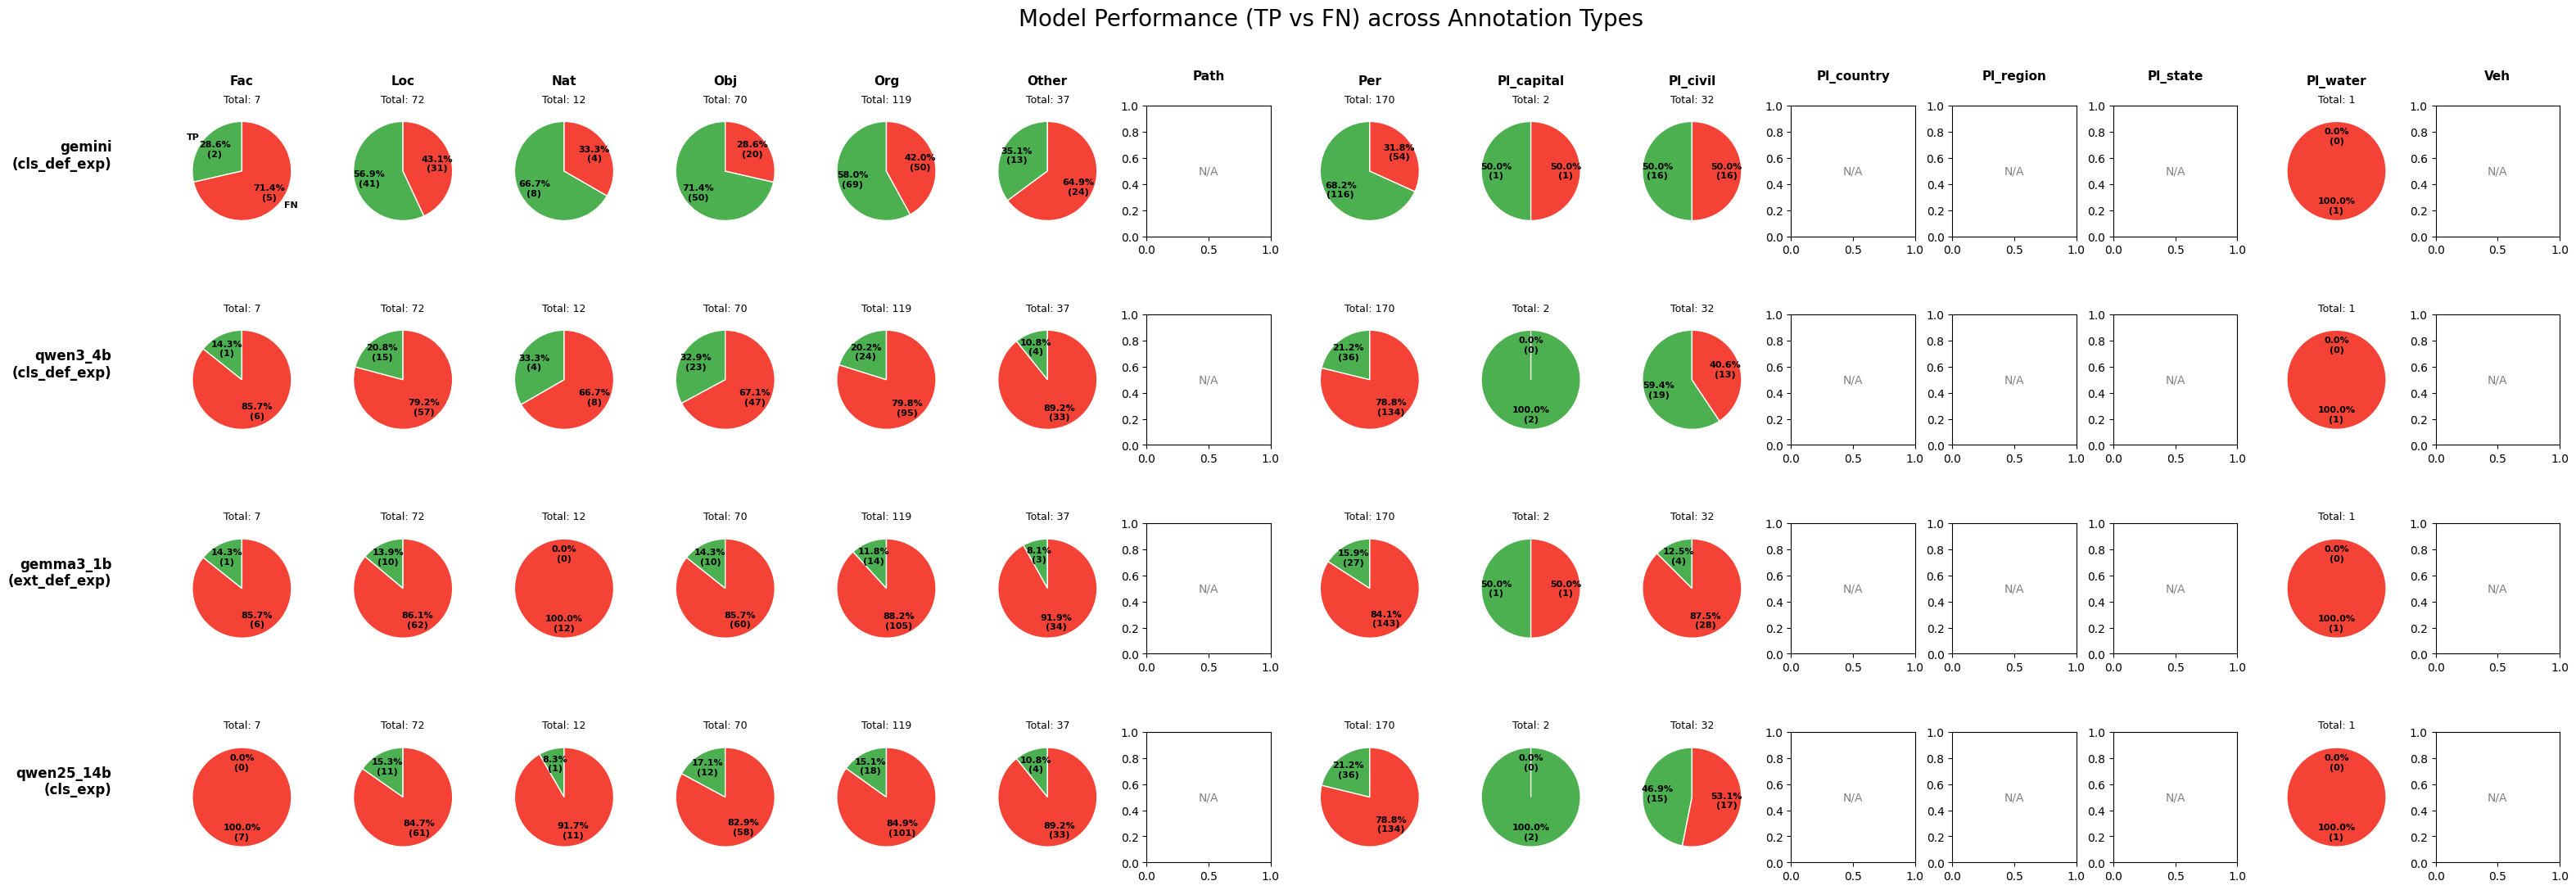

In [17]:
# 1. Define the targets and annotation types
targets = get_best_templates(BEST_TEMPLATES, "portuguese")

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn[
            (df_sorted_tp_fn['modelo'] == modelo) & 
            (df_sorted_tp_fn['template'] == template) & 
            (df_sorted_tp_fn['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

#### English

In [18]:
raw_results_analysis =pd.read_csv("../results/prompt_selection/english/detailed_results.csv")
raw_results_analysis.head()

,modelo,entity,doc_id,template,token,pred_type,annt_type,result,f1_r_score
0,gemini,participants,lusa_100,cls,Lisbon,Loc,Pl_capital,tp,NaN
1,gemini,participants,lusa_100,cls,Man,Per,Per,tp,NaN
2,gemini,participants,lusa_100,cls,police forces,Org,Org,tp,NaN
3,gemini,participants,lusa_100,cls,security tapes,Obj,Obj,tp,NaN
4,gemini,participants,lusa_100,cls,A 29-year-old man,Per,Per,tp,NaN


In [19]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df = raw_results_analysis.copy()
df['annt_type'] = df['annt_type'].fillna('MISSING')

counts = (
    df
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot = counts.sort_values(['annt_type', 'template', 'result'])
df_sorted = pivot.sort_values(by='count', ascending=False)
df_sorted_tp = df_sorted[df_sorted['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn = df_sorted_tp.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn.head(50))

,modelo,annt_type,template,count_tp_fn,count_tp
0,gemini,Fac,cls,7,2
1,gemini,Fac,cls_def,7,2
2,gemini,Fac,cls_def_exp,7,2
3,gemini,Fac,cls_exp,7,2
4,gemini,Fac,ext,7,0
5,gemini,Fac,ext_def,7,0
6,gemini,Fac,ext_def_exp,7,2
7,gemini,Fac,ext_exp,7,3
8,gemini,Loc,cls,72,16
9,gemini,Loc,cls_def,72,24


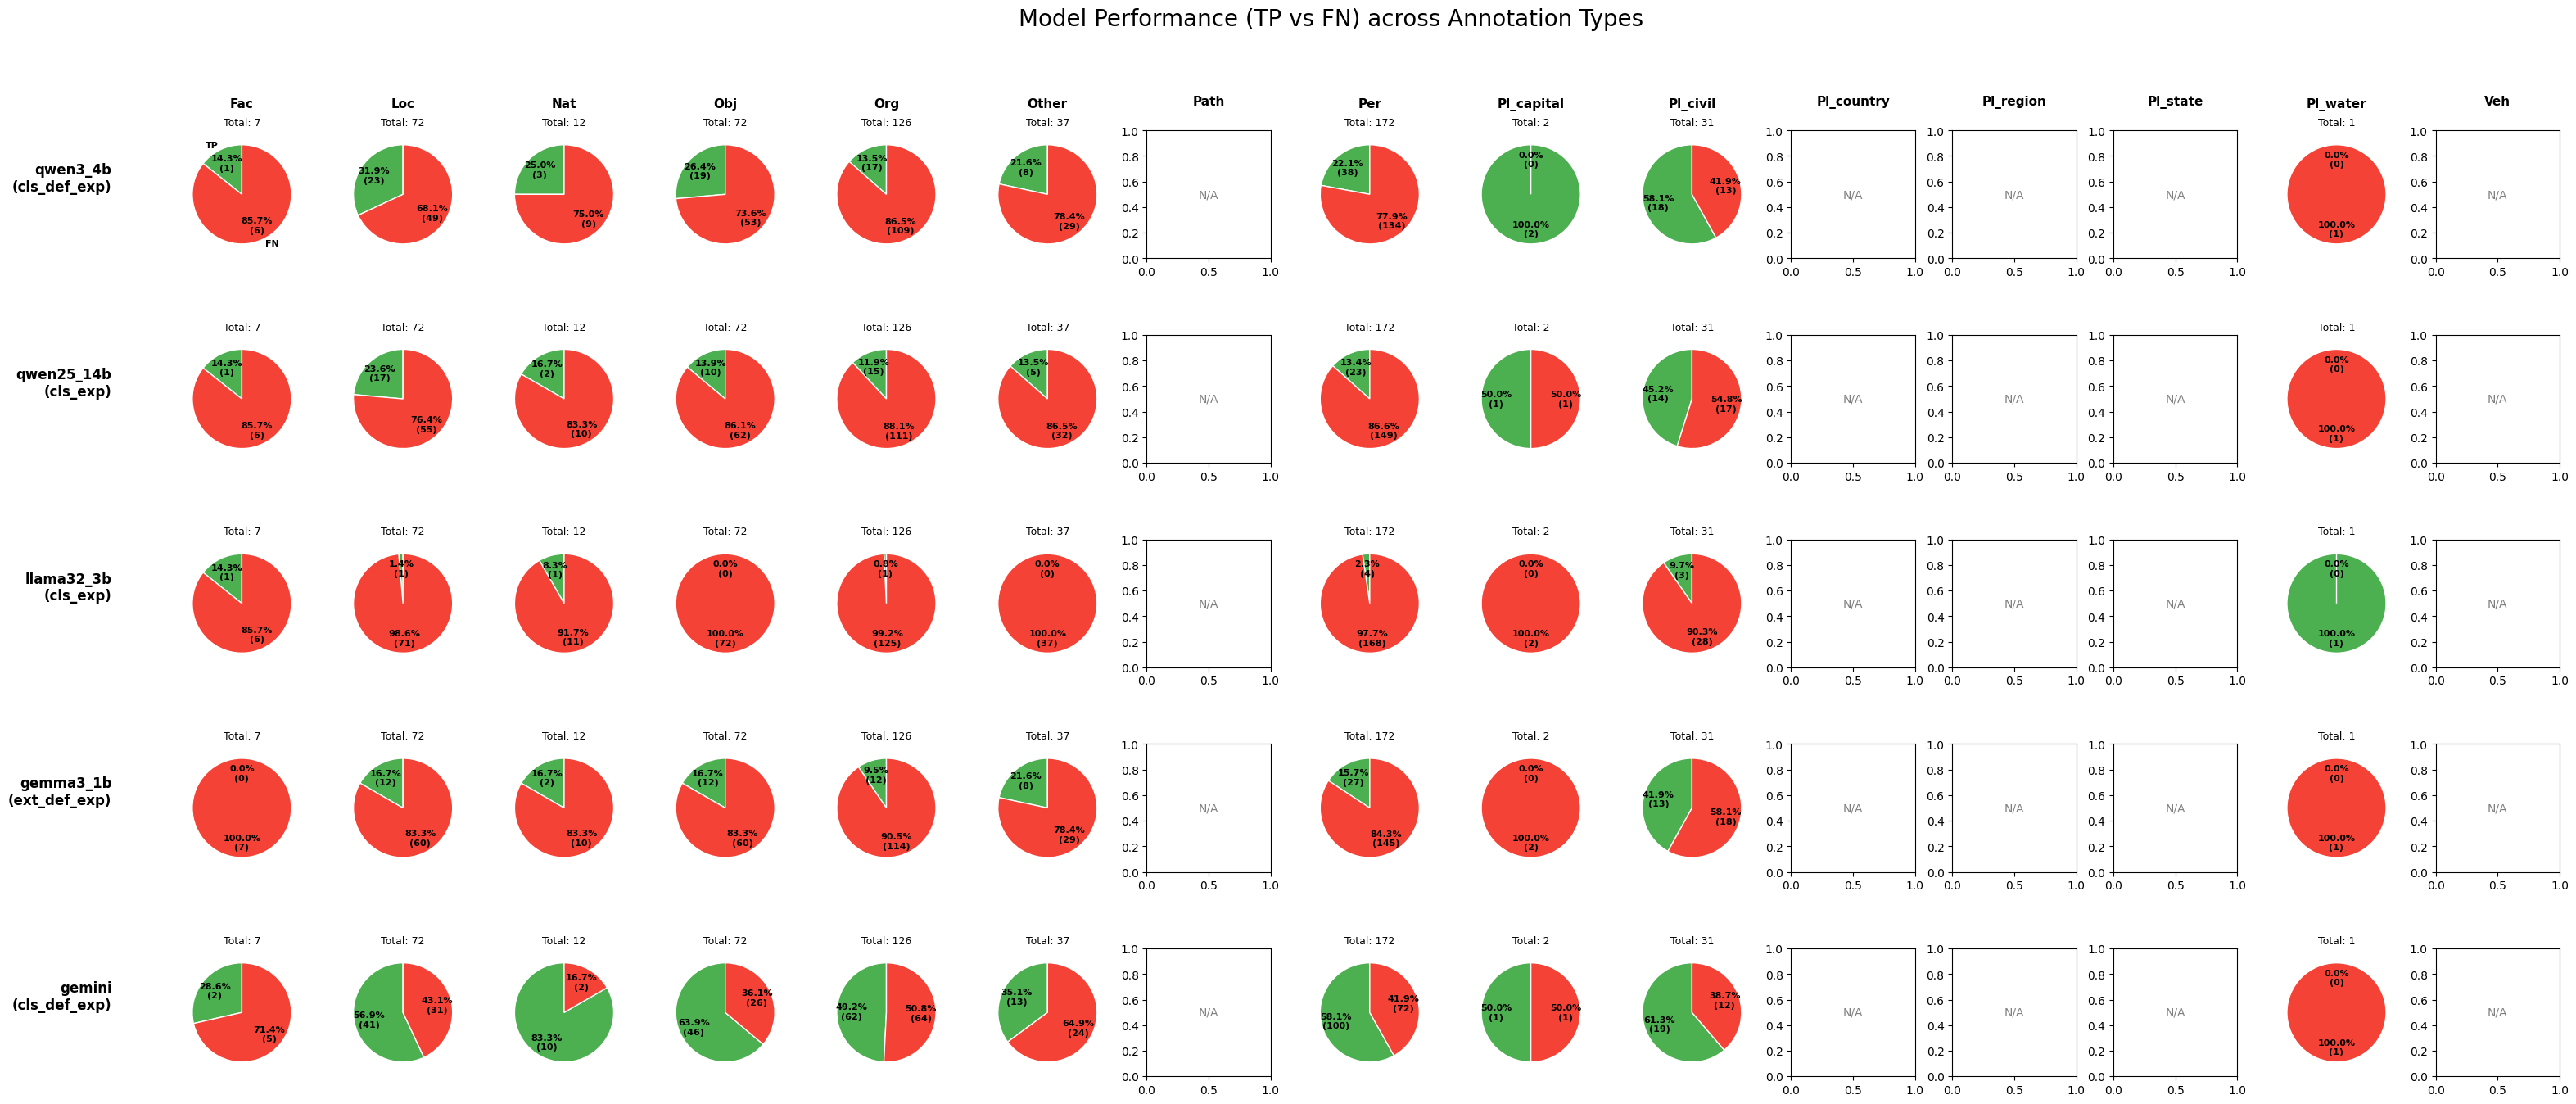

In [20]:
# 1. Define the targets and annotation types
targets = get_best_templates(BEST_TEMPLATES, "english")

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn[
            (df_sorted_tp_fn['modelo'] == modelo) & 
            (df_sorted_tp_fn['template'] == template) & 
            (df_sorted_tp_fn['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

### Relaxed Metrics Evaluate (Token level)

#### Portuguese

In [21]:
token_raw_results_analysis =pd.read_csv("../results/prompt_selection/portuguese/detailed_results_token_level.csv")
token_raw_results_analysis.head()

,modelo,entity,doc_id,template,complete_prediction,token,pred_type,matched_annotation,annt_type,result
0,gemini,participants,lusa_100,cls,['lusa'],à,Org,À Lusa,Org,fn
1,gemini,participants,lusa_100,cls,['lusa'],lusa,Org,À Lusa,Org,tp
2,gemini,participants,lusa_100,cls,['pj'],pj,Org,NaN,NaN,fp
3,gemini,participants,lusa_100,cls,"['rua', 'ângela', 'pinto']",na,Loc,na rua Ângela Pinto,Loc,fn
4,gemini,participants,lusa_100,cls,"['rua', 'ângela', 'pinto']",rua,Loc,na rua Ângela Pinto,Loc,tp


In [22]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df_token = token_raw_results_analysis.copy()
df_token['annt_type'] = df_token['annt_type'].fillna('MISSING')

counts_token = (
    df_token
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot_token = counts_token.sort_values(['annt_type', 'template', 'result'])
df_sorted_token = pivot_token.sort_values(by='count', ascending=False)
df_sorted_tp_token = df_sorted_token[df_sorted_token['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn_token = df_sorted_tp_token.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp_token.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn_token.head(50))

,modelo,annt_type,template,count_tp_fn,count_tp
0,gemini,Fac,cls,21,15
1,gemini,Fac,cls_def,21,13
2,gemini,Fac,cls_def_exp,20,17
3,gemini,Fac,cls_exp,23,17
4,gemini,Fac,ext_def,4,3
5,gemini,Fac,ext_def_exp,20,17
6,gemini,Fac,ext_exp,21,17
7,gemini,Loc,cls,194,143
8,gemini,Loc,cls_def,178,134
9,gemini,Loc,cls_def_exp,220,190


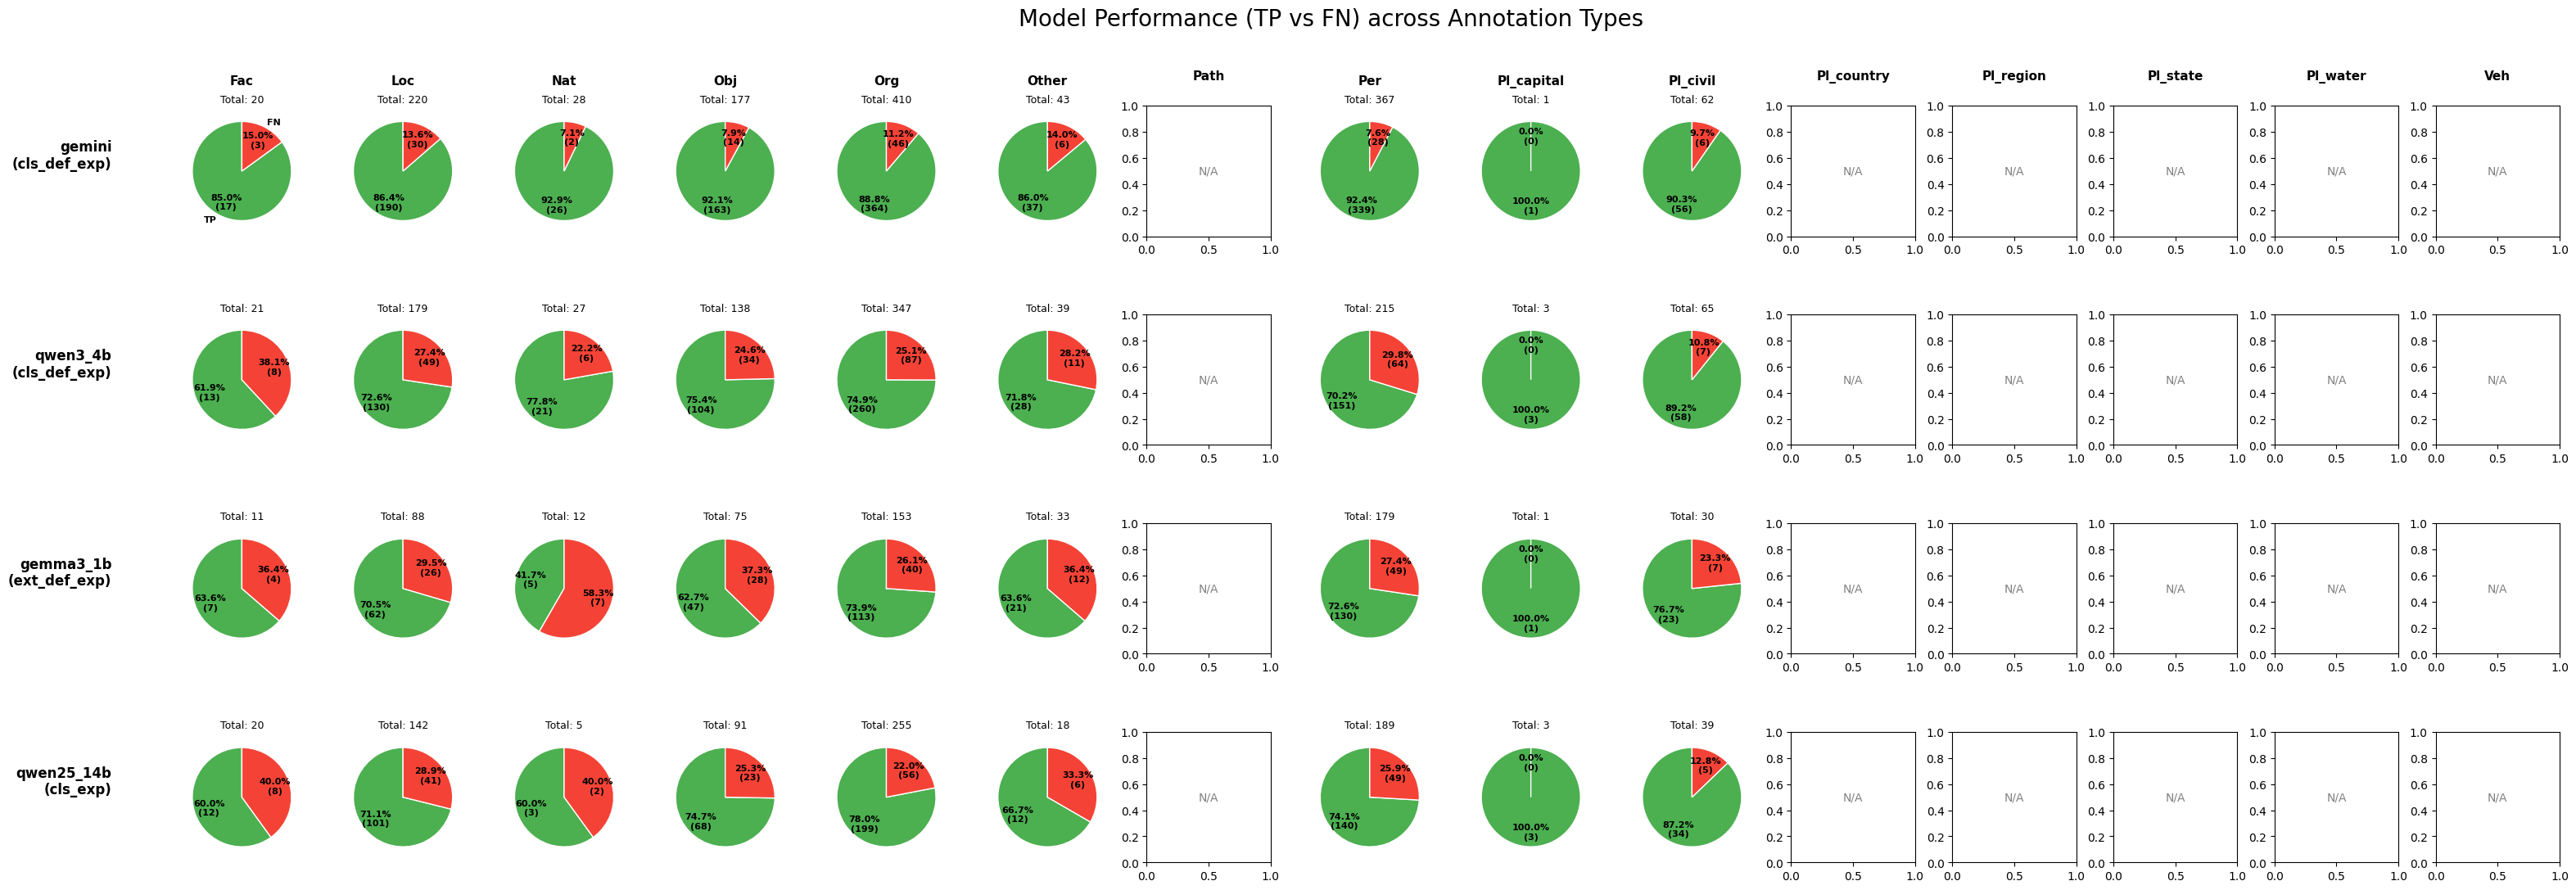

In [23]:
# 1. Define the targets and annotation types
targets = get_best_templates(BEST_TEMPLATES, "portuguese")

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn_token[
            (df_sorted_tp_fn_token['modelo'] == modelo) & 
            (df_sorted_tp_fn_token['template'] == template) & 
            (df_sorted_tp_fn_token['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

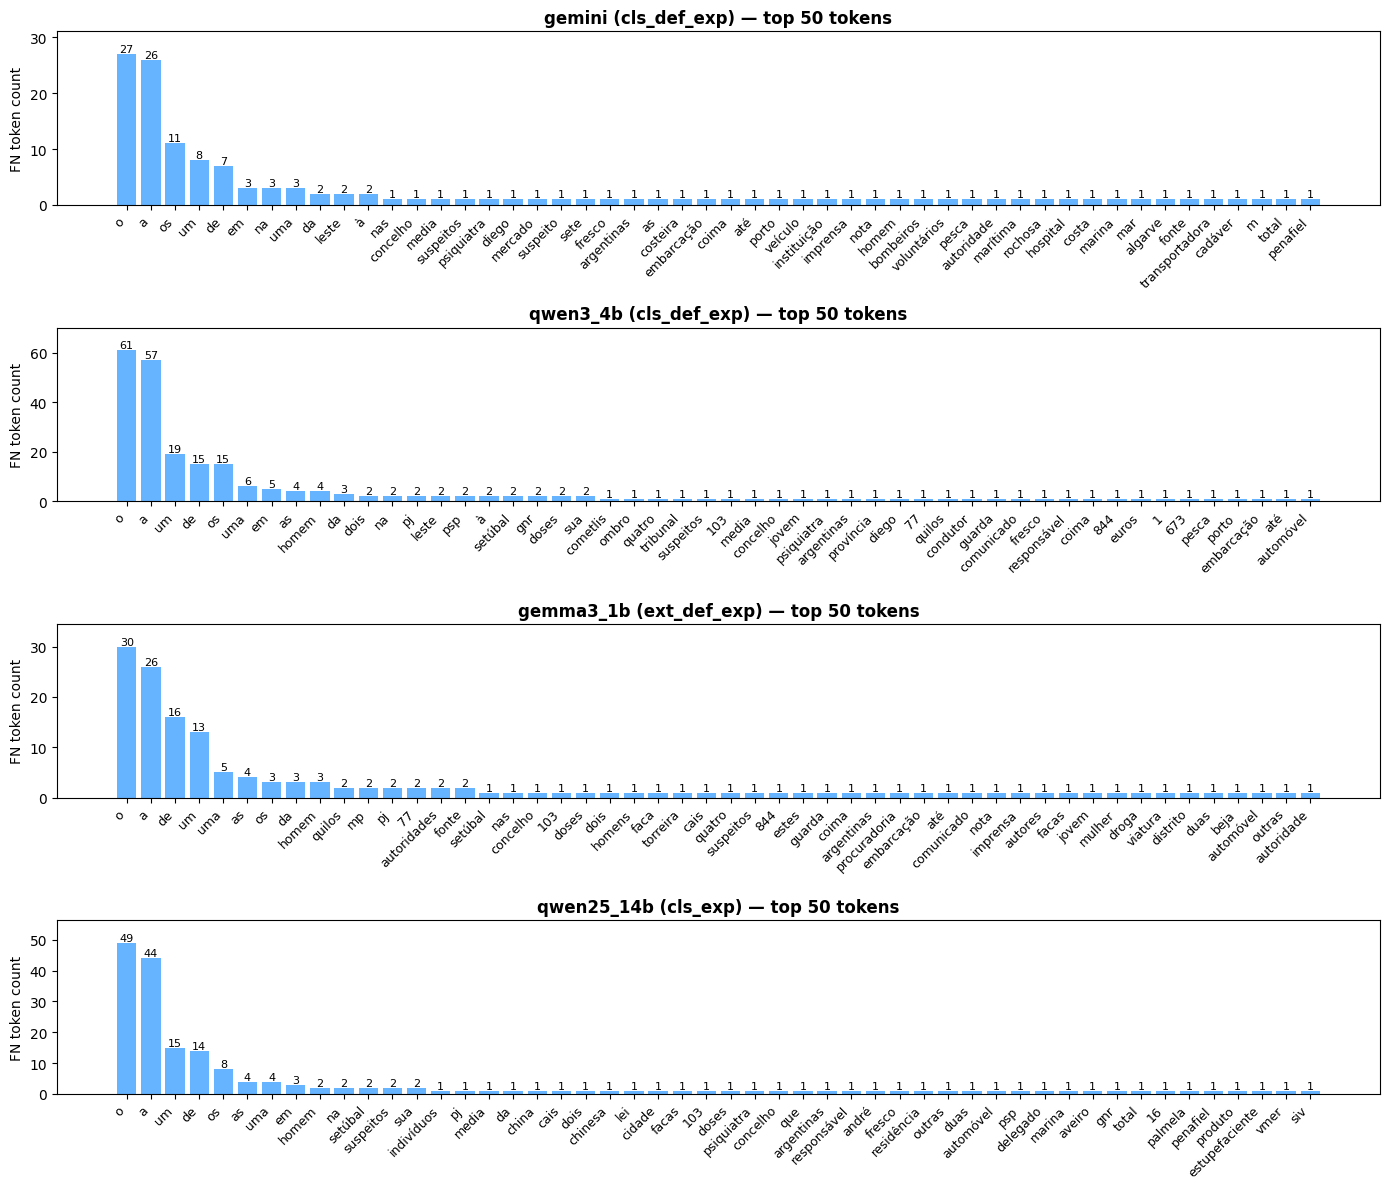

In [24]:
# Bar plot per target/model (token-level TP counts) ordered descending and annotated with counts
targets = get_best_templates(BEST_TEMPLATES, "portuguese")

top_n = 50  # number of top tokens to show per plot
n_rows = len(targets)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3 * n_rows), sharex=False)

if n_rows == 1:
    axes = [axes]

for ax, (modelo, template) in zip(axes, targets):
    subset = token_raw_results_analysis[
        (token_raw_results_analysis['modelo'] == modelo) &
        (token_raw_results_analysis['template'] == template) &
        (token_raw_results_analysis['result'] == 'fn')
    ]
    if subset.empty:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        ax.set_title(f'{modelo} ({template})', fontsize=12, fontweight='bold')
        continue

    token_counts = subset['token'].value_counts().head(top_n)
    labels = token_counts.index.tolist()
    counts = token_counts.values.tolist()

    x = range(len(labels))
    bars = ax.bar(x, counts, color='#66b3ff')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('FN token count', fontsize=10)
    ax.set_title(f'{modelo} ({template}) — top {len(labels)} tokens', fontsize=12, fontweight='bold')
    ax.set_ylim(0, (max(counts) if counts else 1) * 1.15)

    for b, cnt in zip(bars, counts):
        if cnt > 0:
            ax.annotate(f'{int(cnt)}', (b.get_x() + b.get_width() / 2, cnt),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


#### English

In [25]:
token_raw_results_analysis =pd.read_csv("../results/prompt_selection/english/detailed_results_token_level.csv")
token_raw_results_analysis.head()

,modelo,entity,doc_id,template,complete_prediction,token,pred_type,matched_annotation,annt_type,result
0,gemini,participants,lusa_100,cls,"['police', 'source']",police,Per,police forces,Org,tp
1,gemini,participants,lusa_100,cls,"['police', 'source']",source,Per,police forces,Org,fp
2,gemini,participants,lusa_100,cls,"['police', 'source']",forces,Per,police forces,Org,fn
3,gemini,participants,lusa_100,cls,['man'],man,Per,Man,Per,tp
4,gemini,participants,lusa_100,cls,"['lusa', 'agency']",the,Org,the Lusa agency,Org,fn


In [26]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df_token = token_raw_results_analysis.copy()
df_token['annt_type'] = df_token['annt_type'].fillna('MISSING')

counts_token = (
    df_token
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot_token = counts_token.sort_values(['annt_type', 'template', 'result'])
df_sorted_token = pivot_token.sort_values(by='count', ascending=False)
df_sorted_tp_token = df_sorted_token[df_sorted_token['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn_token = df_sorted_tp_token.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp_token.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn_token.head(50))

,modelo,annt_type,template,count_tp_fn,count_tp
0,gemini,Fac,cls,6,5
1,gemini,Fac,cls_def,6,5
2,gemini,Fac,cls_def_exp,8,6
3,gemini,Fac,cls_exp,8,6
4,gemini,Fac,ext_def_exp,6,6
5,gemini,Fac,ext_exp,6,6
6,gemini,Loc,cls,144,98
7,gemini,Loc,cls_def,152,118
8,gemini,Loc,cls_def_exp,182,159
9,gemini,Loc,cls_exp,188,165


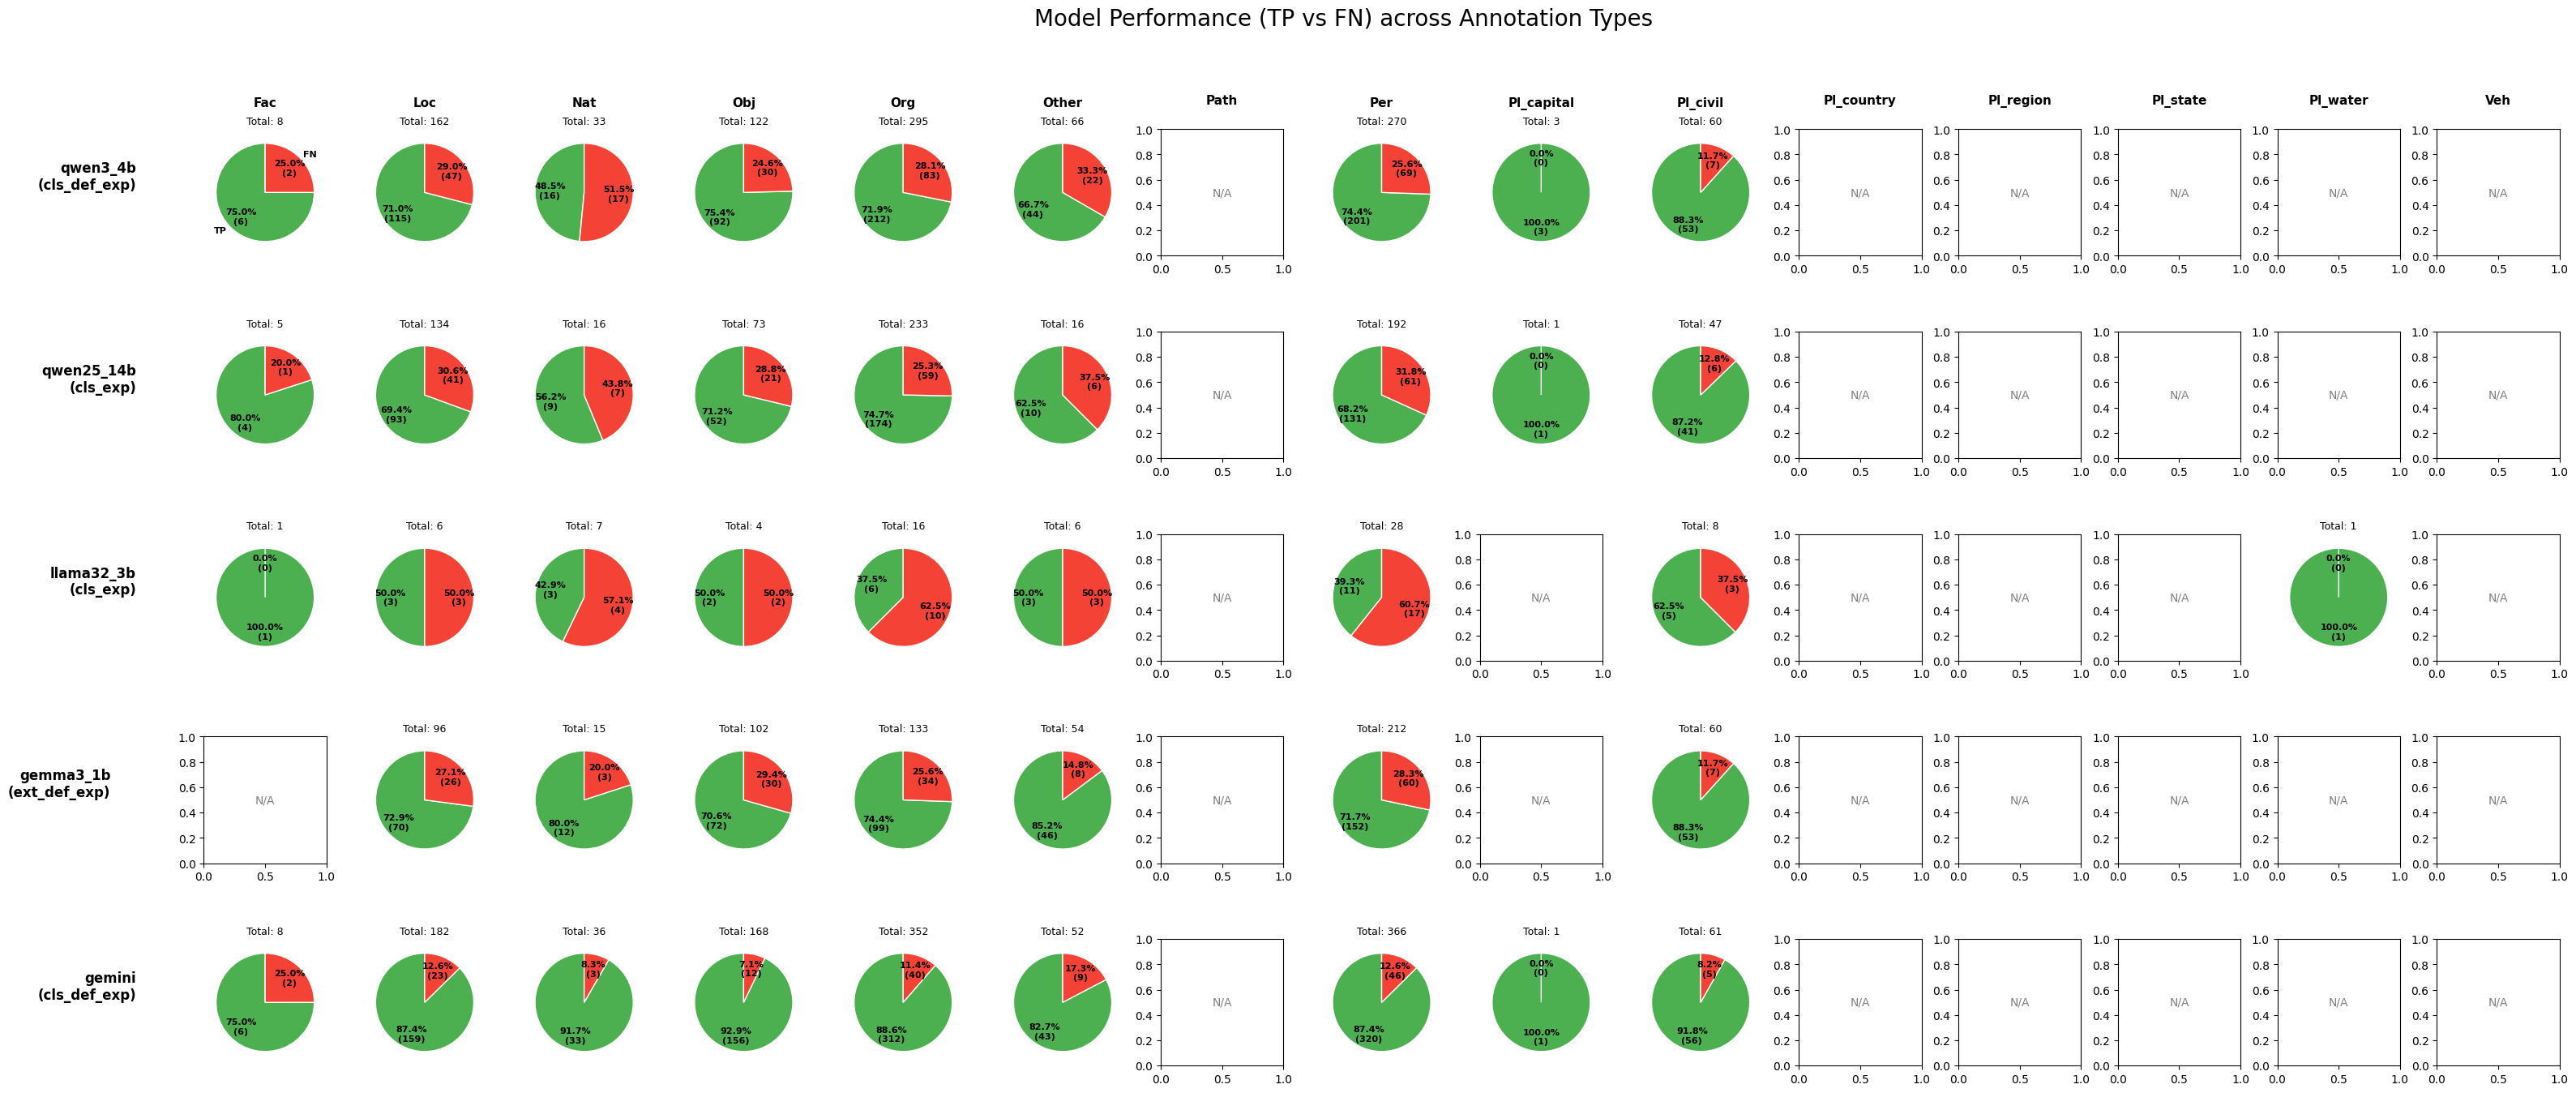

In [27]:
# 1. Define the BEST targets and annotation types
targets = get_best_templates(BEST_TEMPLATES, "english")

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn_token[
            (df_sorted_tp_fn_token['modelo'] == modelo) & 
            (df_sorted_tp_fn_token['template'] == template) & 
            (df_sorted_tp_fn_token['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

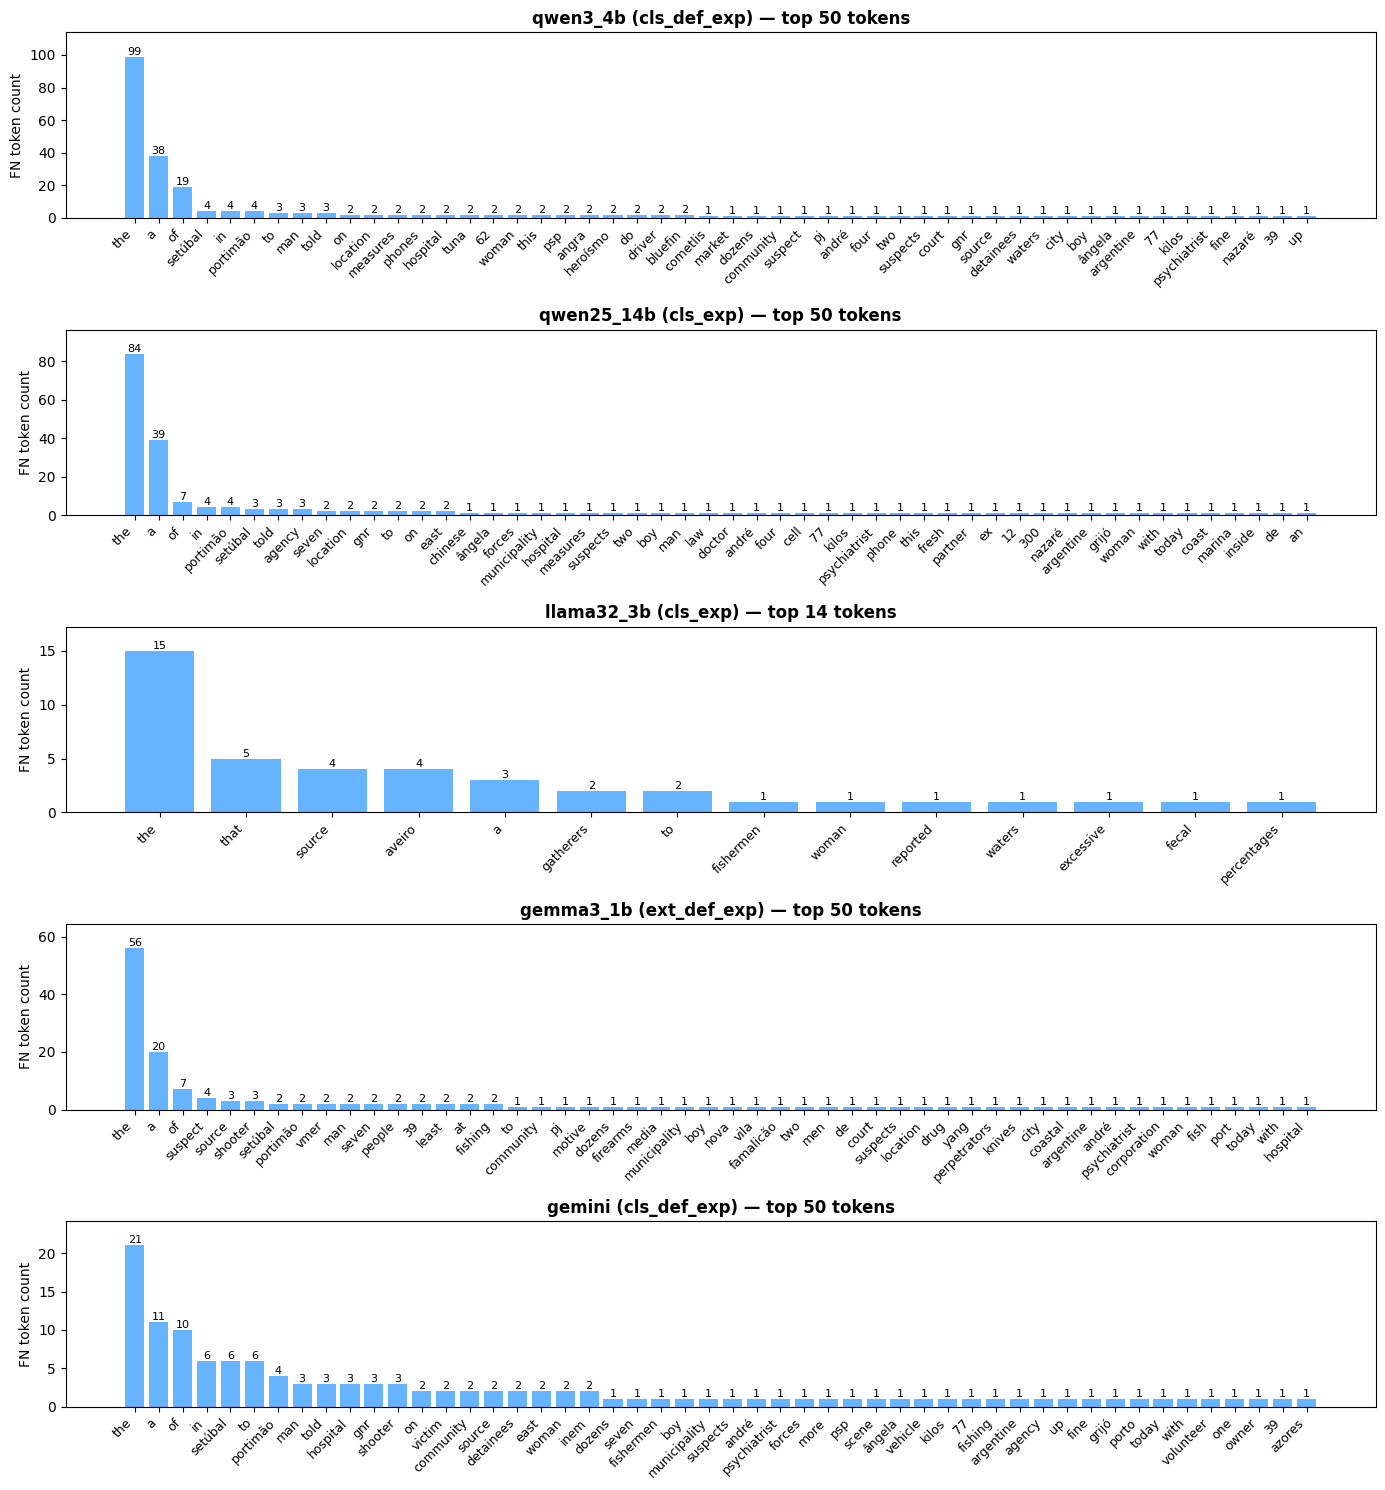

In [28]:
# Bar plot per target/model (token-level TP counts) ordered descending and annotated with counts
targets = get_best_templates(BEST_TEMPLATES, "english")

top_n = 50  # number of top tokens to show per plot
n_rows = len(targets)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3 * n_rows), sharex=False)

if n_rows == 1:
    axes = [axes]

for ax, (modelo, template) in zip(axes, targets):
    subset = token_raw_results_analysis[
        (token_raw_results_analysis['modelo'] == modelo) &
        (token_raw_results_analysis['template'] == template) &
        (token_raw_results_analysis['result'] == 'fn')
    ]
    if subset.empty:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        ax.set_title(f'{modelo} ({template})', fontsize=12, fontweight='bold')
        continue

    token_counts = subset['token'].value_counts().head(top_n)
    labels = token_counts.index.tolist()
    counts = token_counts.values.tolist()

    x = range(len(labels))
    bars = ax.bar(x, counts, color='#66b3ff')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('FN token count', fontsize=10)
    ax.set_title(f'{modelo} ({template}) — top {len(labels)} tokens', fontsize=12, fontweight='bold')
    ax.set_ylim(0, (max(counts) if counts else 1) * 1.15)

    for b, cnt in zip(bars, counts):
        if cnt > 0:
            ax.annotate(f'{int(cnt)}', (b.get_x() + b.get_width() / 2, cnt),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


## Test

### Strict Metrics Evaluate

#### Portuguese 

In [29]:
raw_results_analysis =pd.read_csv("../results/test/portuguese/detailed_results.csv")
raw_results_analysis.head()

,modelo,entity,doc_id,template,token,pred_type,annt_type,result,f1_r_score
0,gemini,participants,lusa_1,cls_def_exp,Corotelo,NaN,Pl_civil,tp,NaN
1,gemini,participants,lusa_1,cls_def_exp,Os militares,NaN,Per,tp,NaN
2,gemini,participants,lusa_1,cls_def_exp,um auto de contraordenação,NaN,Obj,tp,NaN
3,gemini,participants,lusa_1,cls_def_exp,A GNR,NaN,Org,tp,NaN
4,gemini,participants,lusa_1,cls_def_exp,o proprietário,NaN,Per,tp,NaN


In [30]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df = raw_results_analysis.copy()
df['annt_type'] = df['annt_type'].fillna('MISSING')

counts = (
    df
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot = counts.sort_values(['annt_type', 'template', 'result'])
df_sorted = pivot.sort_values(by='count', ascending=False)
df_sorted_tp = df_sorted[df_sorted['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn = df_sorted_tp.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn[['modelo', 'template']].drop_duplicates())

,modelo,template
0,gemini,cls_def_exp
16,gemma3_1b,ext_def_exp
32,qwen25_14b,cls_exp
48,qwen3_4b,cls_def_exp


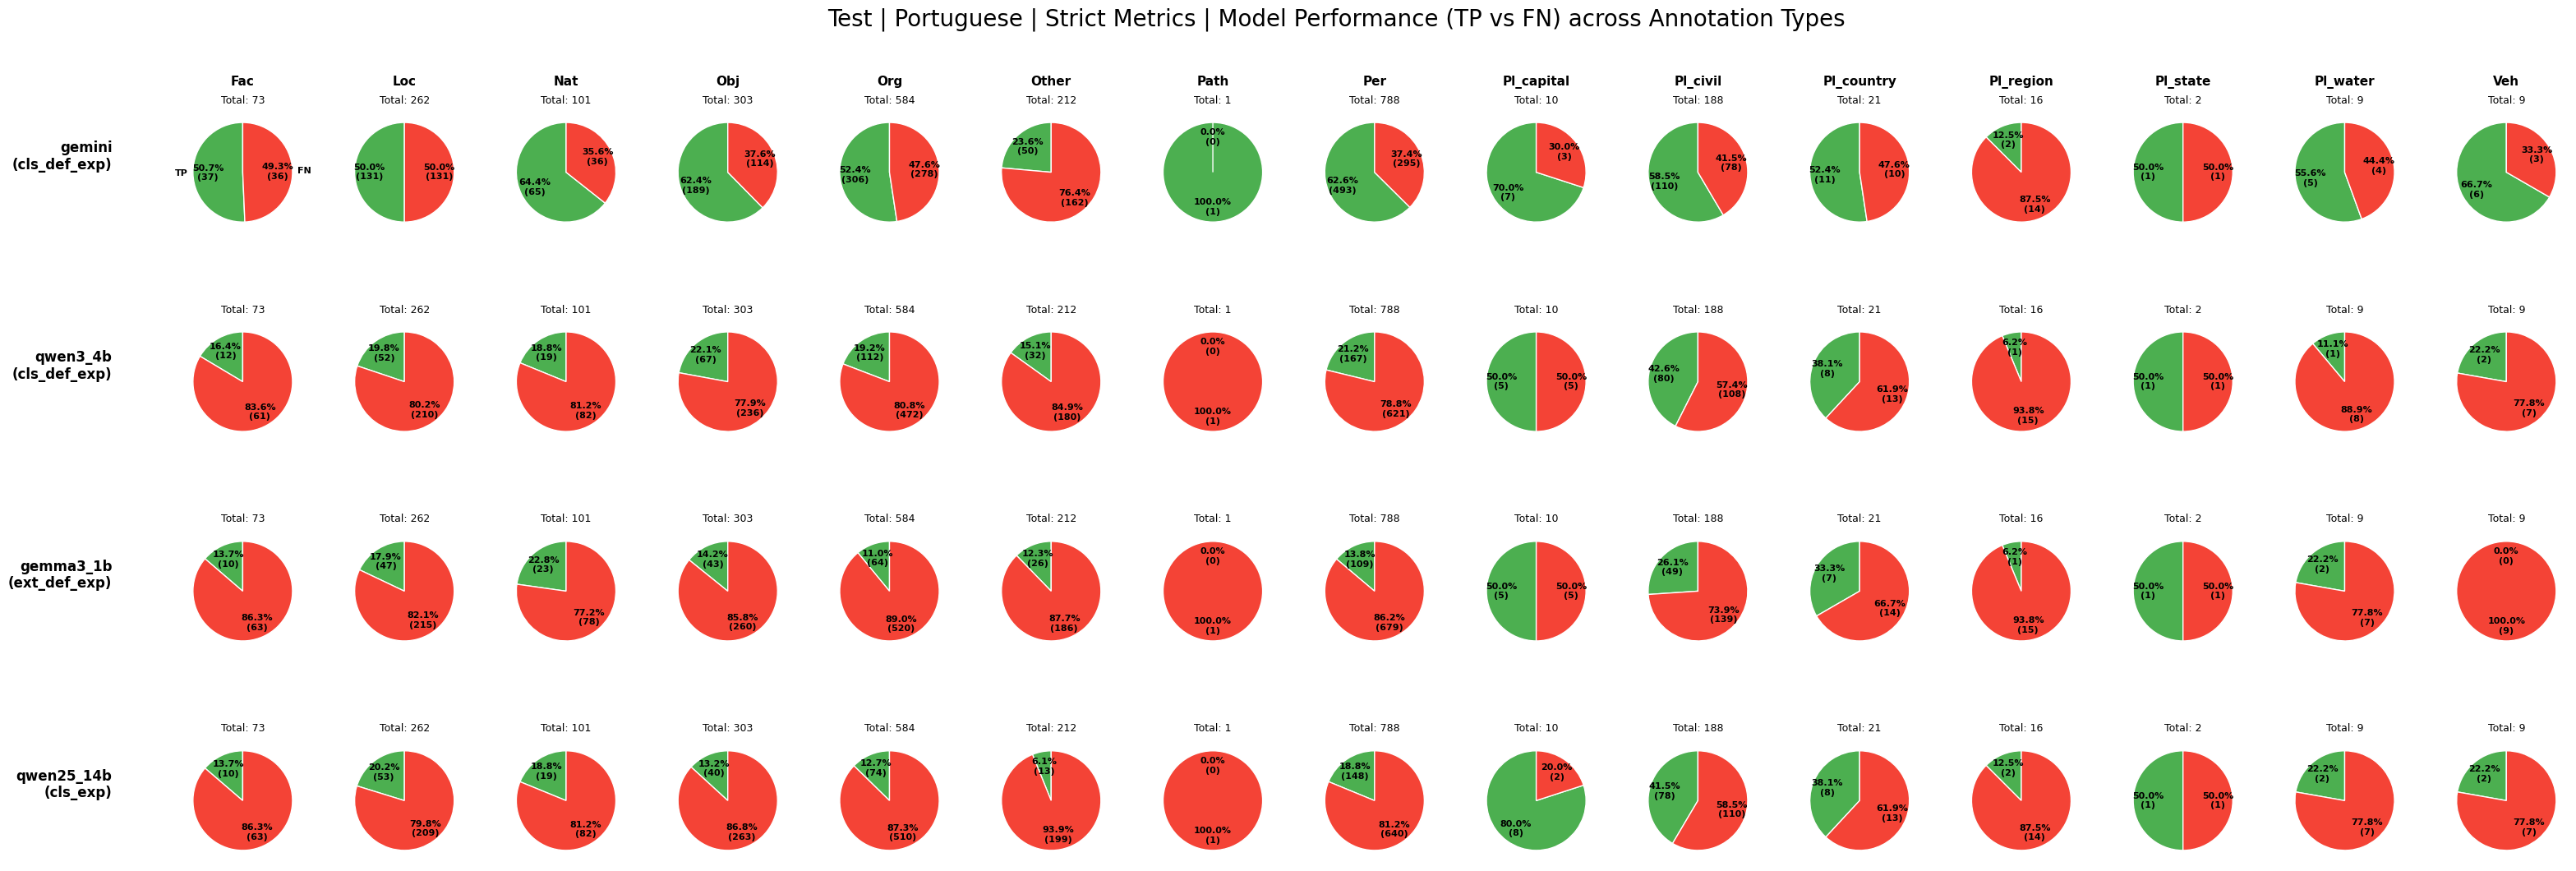

In [31]:
# 1. Define the targets and annotation types
targets = get_best_templates(BEST_TEMPLATES, "portuguese")

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn[
            (df_sorted_tp_fn['modelo'] == modelo) & 
            (df_sorted_tp_fn['template'] == template) & 
            (df_sorted_tp_fn['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Test | Portuguese | Strict Metrics | Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

#### English

In [32]:
raw_results_analysis =pd.read_csv("../results/test/english/detailed_results.csv")
raw_results_analysis.head()

,modelo,entity,doc_id,template,token,pred_type,annt_type,result,f1_r_score
0,gemini,participants,lusa_1,cls_def_exp,GNR,Org,Org,tp,NaN
1,gemini,participants,lusa_1,cls_def_exp,the owner,Per,Per,tp,NaN
2,gemini,participants,lusa_1,cls_def_exp,around 50 people,Per,Per,tp,NaN
3,gemini,participants,lusa_1,cls_def_exp,The military,Per,Per,tp,NaN
4,gemini,participants,lusa_1,cls_def_exp,people,Per,Per,tp,NaN


In [33]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df = raw_results_analysis.copy()
df['annt_type'] = df['annt_type'].fillna('MISSING')

counts = (
    df
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot = counts.sort_values(['annt_type', 'template', 'result'])
df_sorted = pivot.sort_values(by='count', ascending=False)
df_sorted_tp = df_sorted[df_sorted['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn = df_sorted_tp.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn_token[['modelo', 'template']].drop_duplicates())

,modelo,template
0,gemini,cls
1,gemini,cls_def
2,gemini,cls_def_exp
3,gemini,cls_exp
4,gemini,ext_def_exp
5,gemini,ext_exp
10,gemini,ext_def
29,gemini,ext
70,gemma3_1b,cls_def
71,gemma3_1b,cls


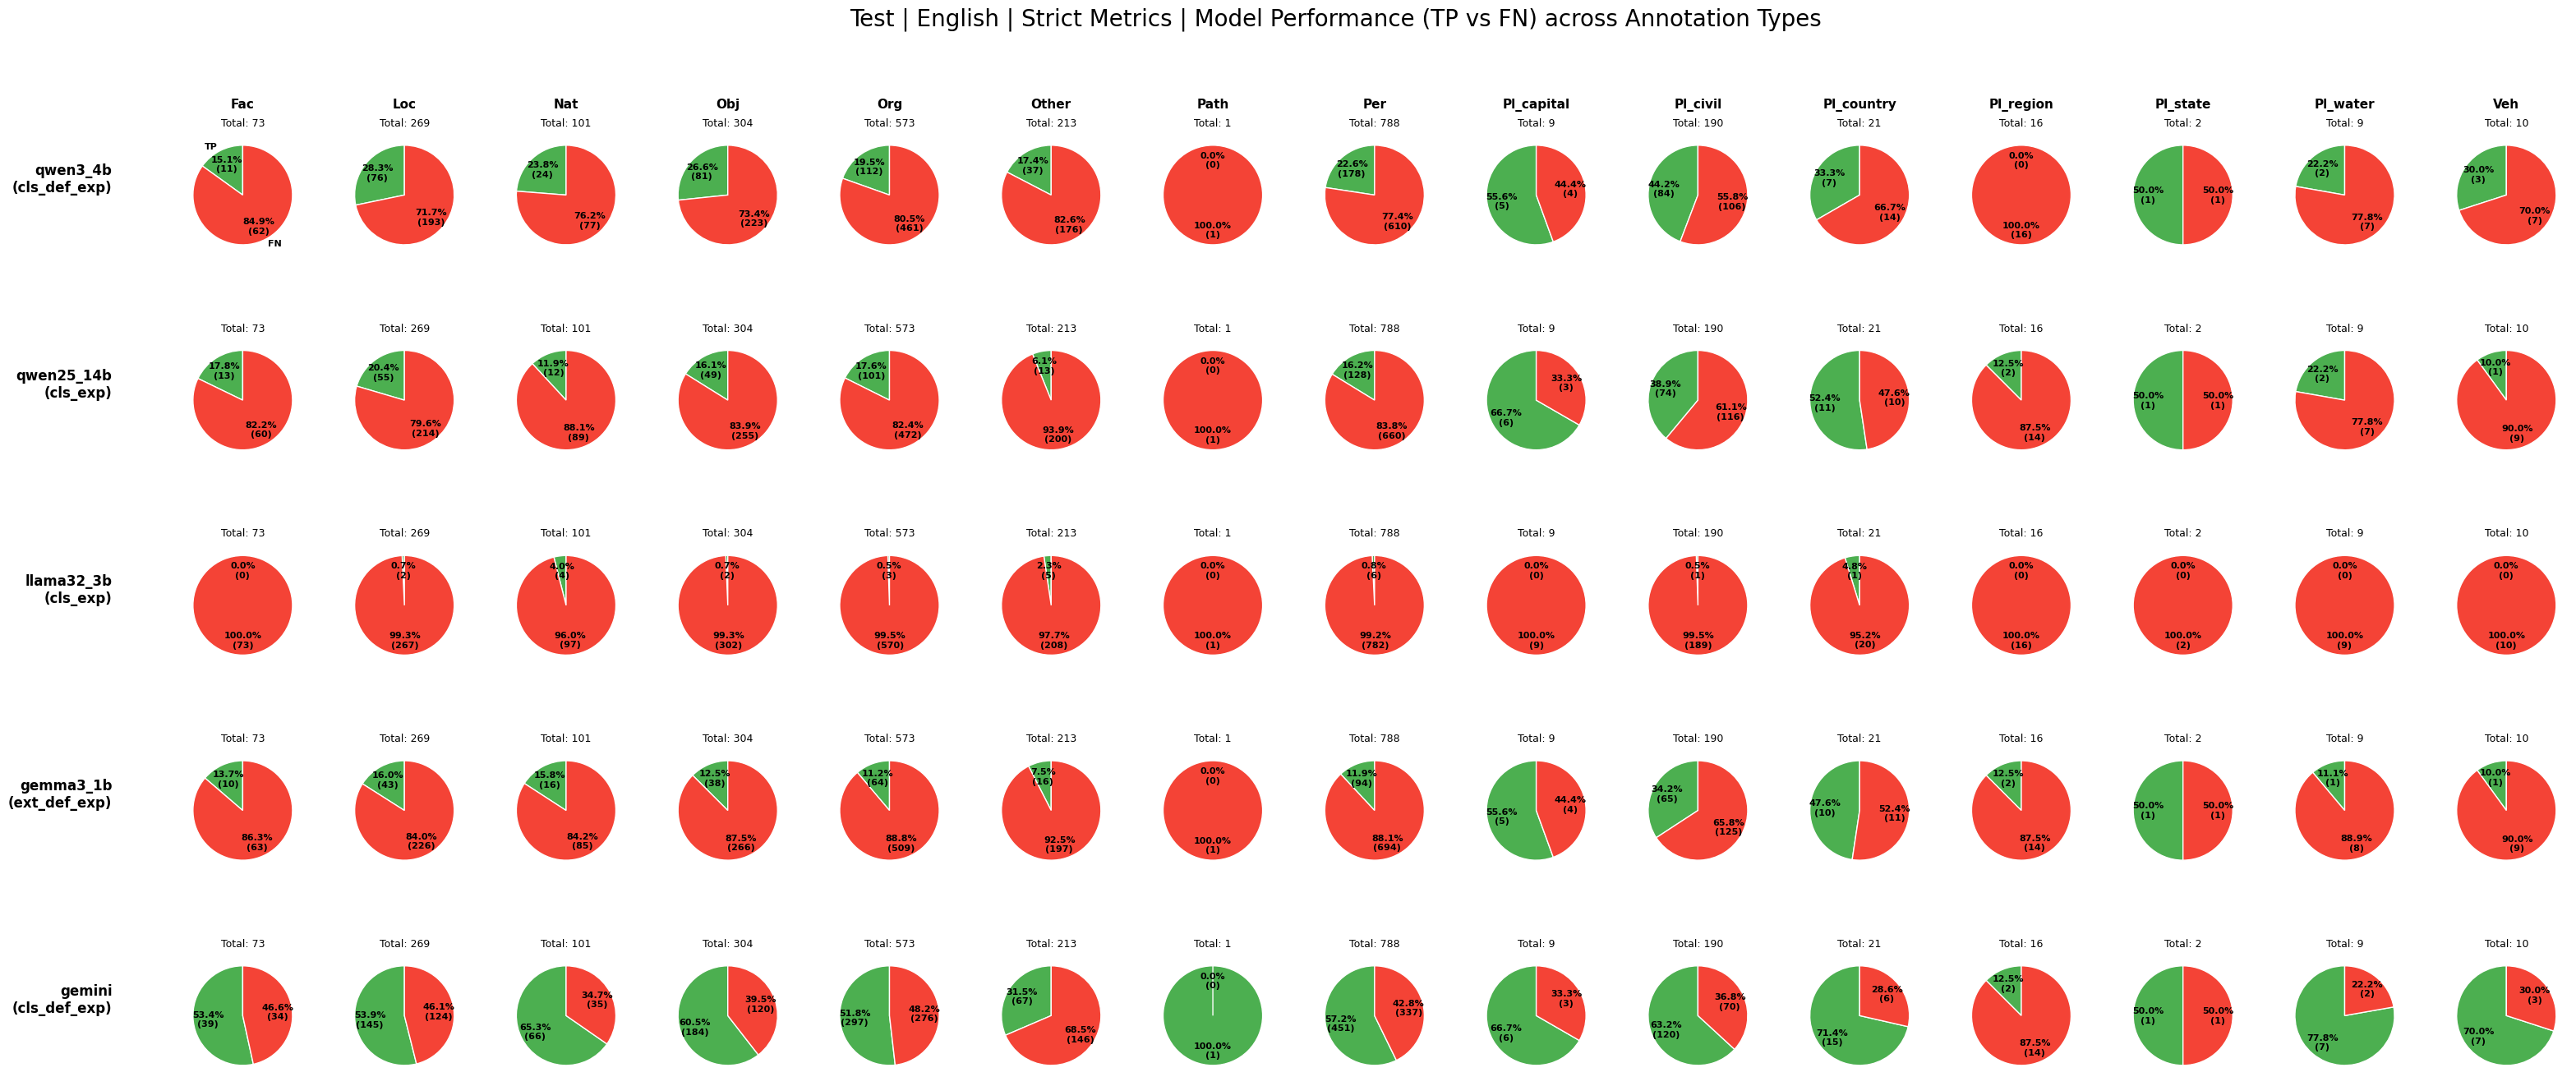

In [34]:
# 1. Define the targets and annotation types
targets = get_best_templates(BEST_TEMPLATES, "english")

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn[
            (df_sorted_tp_fn['modelo'] == modelo) & 
            (df_sorted_tp_fn['template'] == template) & 
            (df_sorted_tp_fn['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Test | English | Strict Metrics | Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

### Relaxed Metrics Evaluate (Token level)

#### Portuguese

In [35]:
token_raw_results_analysis =pd.read_csv("../results/test/portuguese/detailed_results_token_level.csv")
token_raw_results_analysis.head()

,modelo,entity,doc_id,template,complete_prediction,token,pred_type,matched_annotation,annt_type,result
0,gemini,participants,lusa_1,cls_def_exp,"['os', 'militares']",os,Per,Os militares,Per,tp
1,gemini,participants,lusa_1,cls_def_exp,"['os', 'militares']",militares,Per,Os militares,Per,tp
2,gemini,participants,lusa_1,cls_def_exp,"['a', 'gnr']",a,Org,A GNR,Org,tp
3,gemini,participants,lusa_1,cls_def_exp,"['a', 'gnr']",gnr,Org,A GNR,Org,tp
4,gemini,participants,lusa_1,cls_def_exp,"['um', 'bar']",um,Fac,bar,Fac,fp


In [36]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df_token = token_raw_results_analysis.copy()
df_token['annt_type'] = df_token['annt_type'].fillna('MISSING')

counts_token = (
    df_token
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot_token = counts_token.sort_values(['annt_type', 'template', 'result'])
df_sorted_token = pivot_token.sort_values(by='count', ascending=False)
df_sorted_tp_token = df_sorted_token[df_sorted_token['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn_token = df_sorted_tp_token.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp_token.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn_token[['modelo', 'template']].drop_duplicates())

,modelo,template
0,gemini,cls_def_exp
15,gemma3_1b,ext_def_exp
29,qwen25_14b,cls_exp
44,qwen3_4b,cls_def_exp


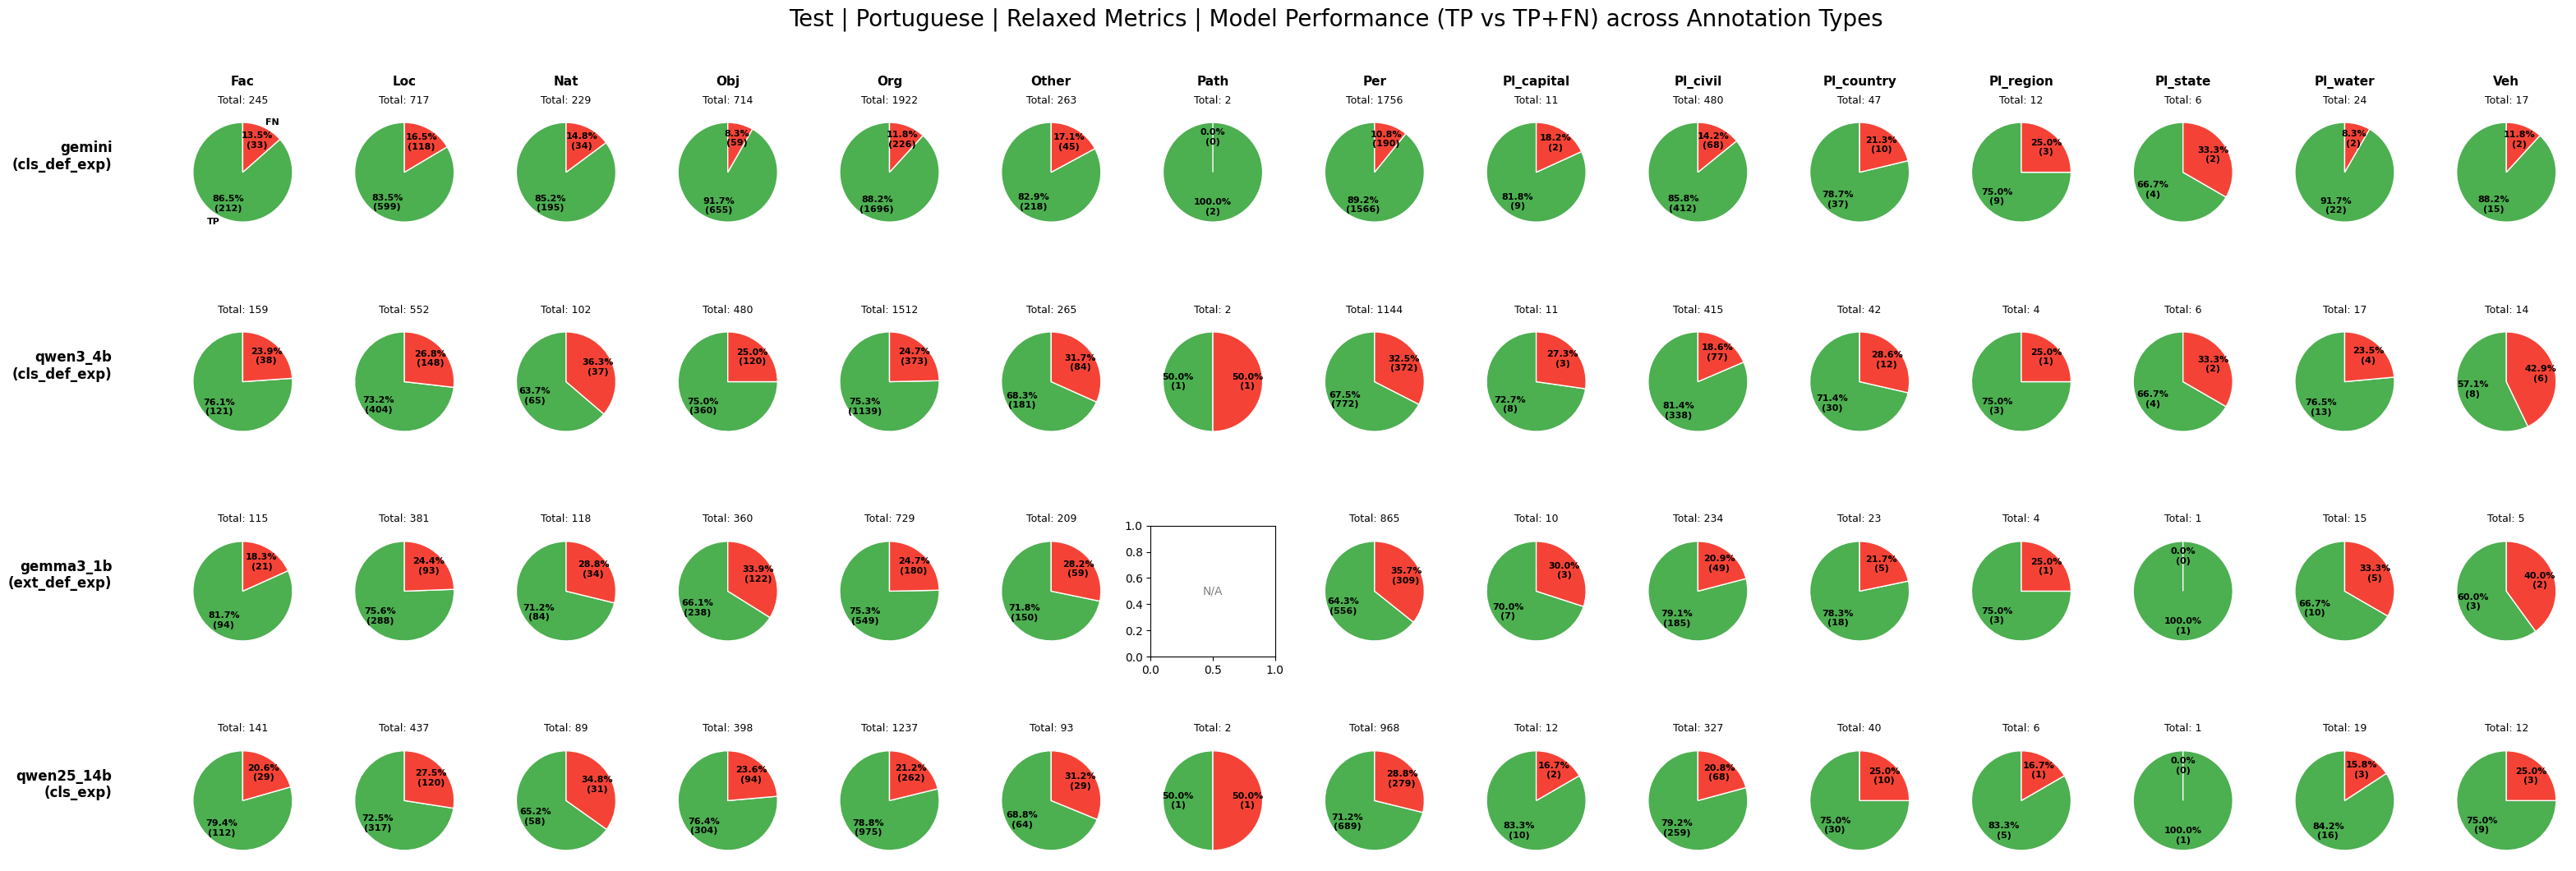

In [37]:
# 1. Define the targets and annotation types
targets = get_best_templates(BEST_TEMPLATES, "portuguese")

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn_token[
            (df_sorted_tp_fn_token['modelo'] == modelo) & 
            (df_sorted_tp_fn_token['template'] == template) & 
            (df_sorted_tp_fn_token['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Test | Portuguese | Relaxed Metrics | Model Performance (TP vs TP+FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

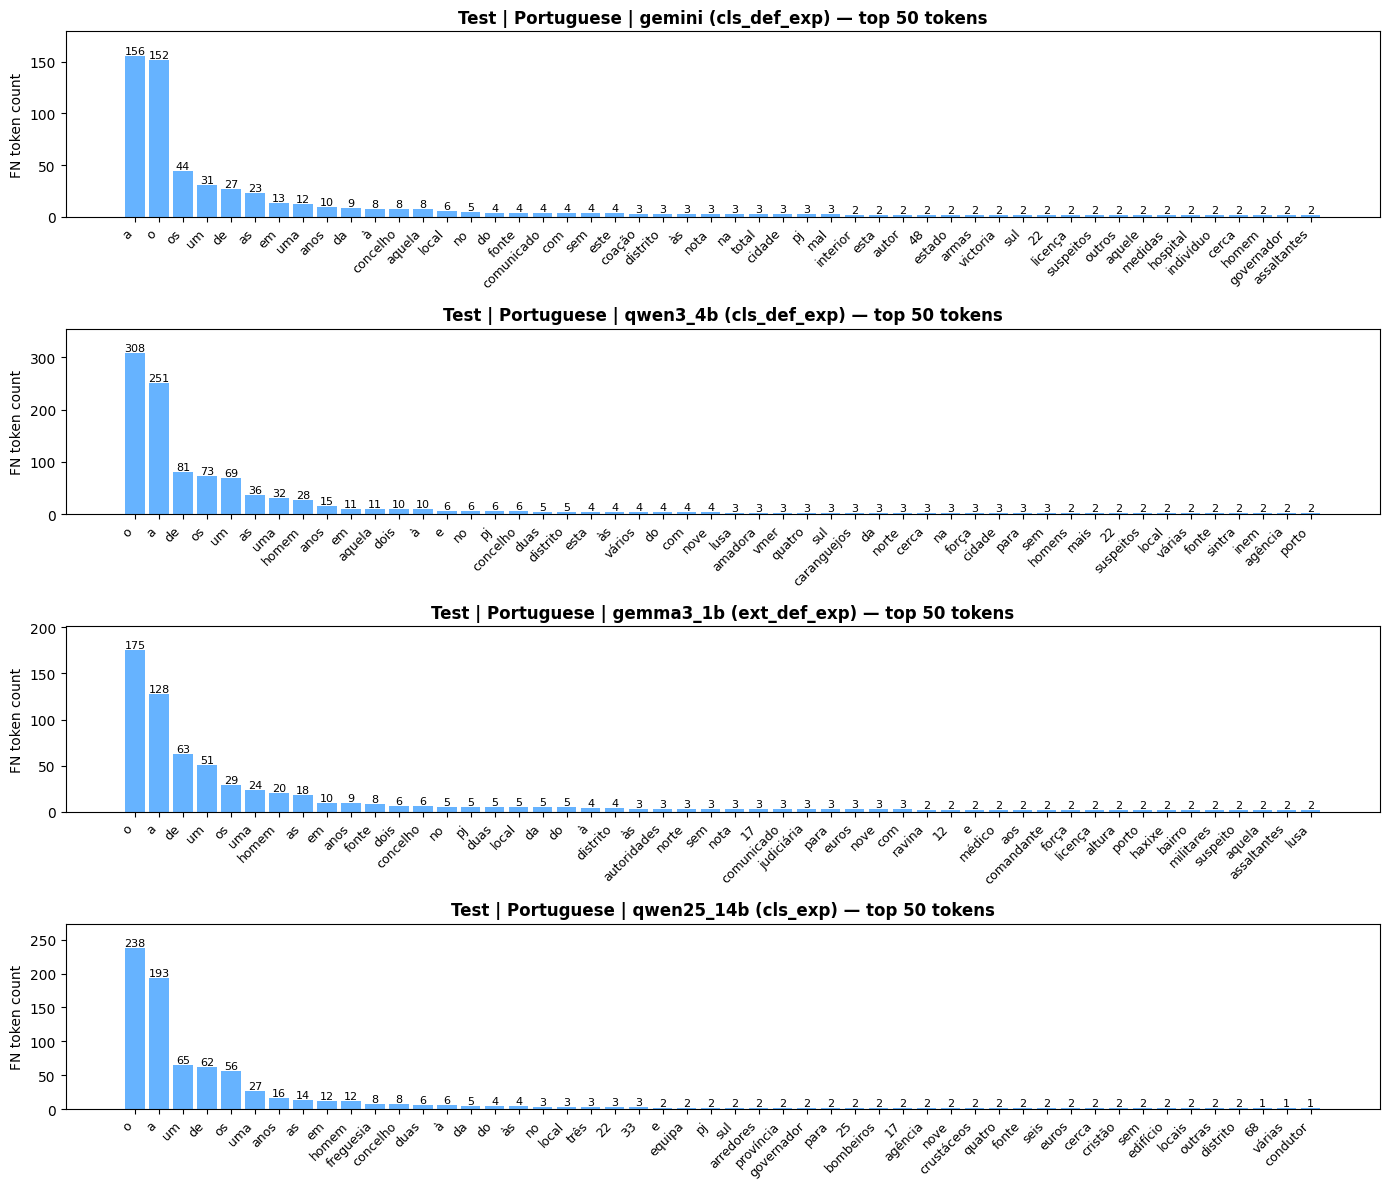

In [38]:
top_n = 50  # number of top tokens to show per plot
n_rows = len(targets)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3 * n_rows), sharex=False)

if n_rows == 1:
    axes = [axes]

for ax, (modelo, template) in zip(axes, targets):
    subset = token_raw_results_analysis[
        (token_raw_results_analysis['modelo'] == modelo) &
        (token_raw_results_analysis['template'] == template) &
        (token_raw_results_analysis['result'] == 'fn')
    ]
    if subset.empty:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        ax.set_title(f'{modelo} ({template})', fontsize=12, fontweight='bold')
        continue

    token_counts = subset['token'].value_counts().head(top_n)
    labels = token_counts.index.tolist()
    counts = token_counts.values.tolist()

    x = range(len(labels))
    bars = ax.bar(x, counts, color='#66b3ff')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('FN token count', fontsize=10)
    ax.set_title(f'Test | Portuguese | {modelo} ({template}) — top {len(labels)} tokens', fontsize=12, fontweight='bold')
    ax.set_ylim(0, (max(counts) if counts else 1) * 1.15)

    for b, cnt in zip(bars, counts):
        if cnt > 0:
            ax.annotate(f'{int(cnt)}', (b.get_x() + b.get_width() / 2, cnt),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


#### English

In [39]:
token_raw_results_analysis =pd.read_csv("../results/test/english/detailed_results_token_level.csv")
token_raw_results_analysis.head()

,modelo,entity,doc_id,template,complete_prediction,token,pred_type,matched_annotation,annt_type,result
0,gemini,participants,lusa_1,cls_def_exp,"['the', 'incident']",the,Obj,The military,Per,tp
1,gemini,participants,lusa_1,cls_def_exp,"['the', 'incident']",incident,Obj,The military,Per,fp
2,gemini,participants,lusa_1,cls_def_exp,"['the', 'incident']",military,Obj,The military,Per,fn
3,gemini,participants,lusa_1,cls_def_exp,"['the', 'gnr']",the,Org,the GNR,Org,tp
4,gemini,participants,lusa_1,cls_def_exp,"['the', 'gnr']",gnr,Org,the GNR,Org,tp


In [40]:
# count results grouped by annt_type and template (treat missing annt_type explicitly)
df_token = token_raw_results_analysis.copy()
df_token['annt_type'] = df_token['annt_type'].fillna('MISSING')

counts_token = (
    df_token
    .groupby(['modelo', 'annt_type', 'template', 'result'])
    .size()
    .reset_index(name='count')
)
# tabular and pivot views
pivot_token = counts_token.sort_values(['annt_type', 'template', 'result'])
df_sorted_token = pivot_token.sort_values(by='count', ascending=False)
df_sorted_tp_token = df_sorted_token[df_sorted_token['result'].isin(['tp', 'fn'])]

# Create count_tp_fn and count_tp columns
df_sorted_tp_fn_token = df_sorted_tp_token.groupby(['modelo', 'annt_type', 'template']).agg(
    count_tp_fn=('count', 'sum'),
    count_tp=('count', lambda x: x[df_sorted_tp_token.loc[x.index, 'result'] == 'tp'].sum())
).reset_index()

display(df_sorted_tp_fn_token[['modelo', 'template']].drop_duplicates())

,modelo,template
0,gemini,cls_def_exp
16,gemma3_1b,ext_def_exp
32,llama32_3b,cls_exp
40,qwen25_14b,cls_exp
55,qwen3_4b,cls_def_exp


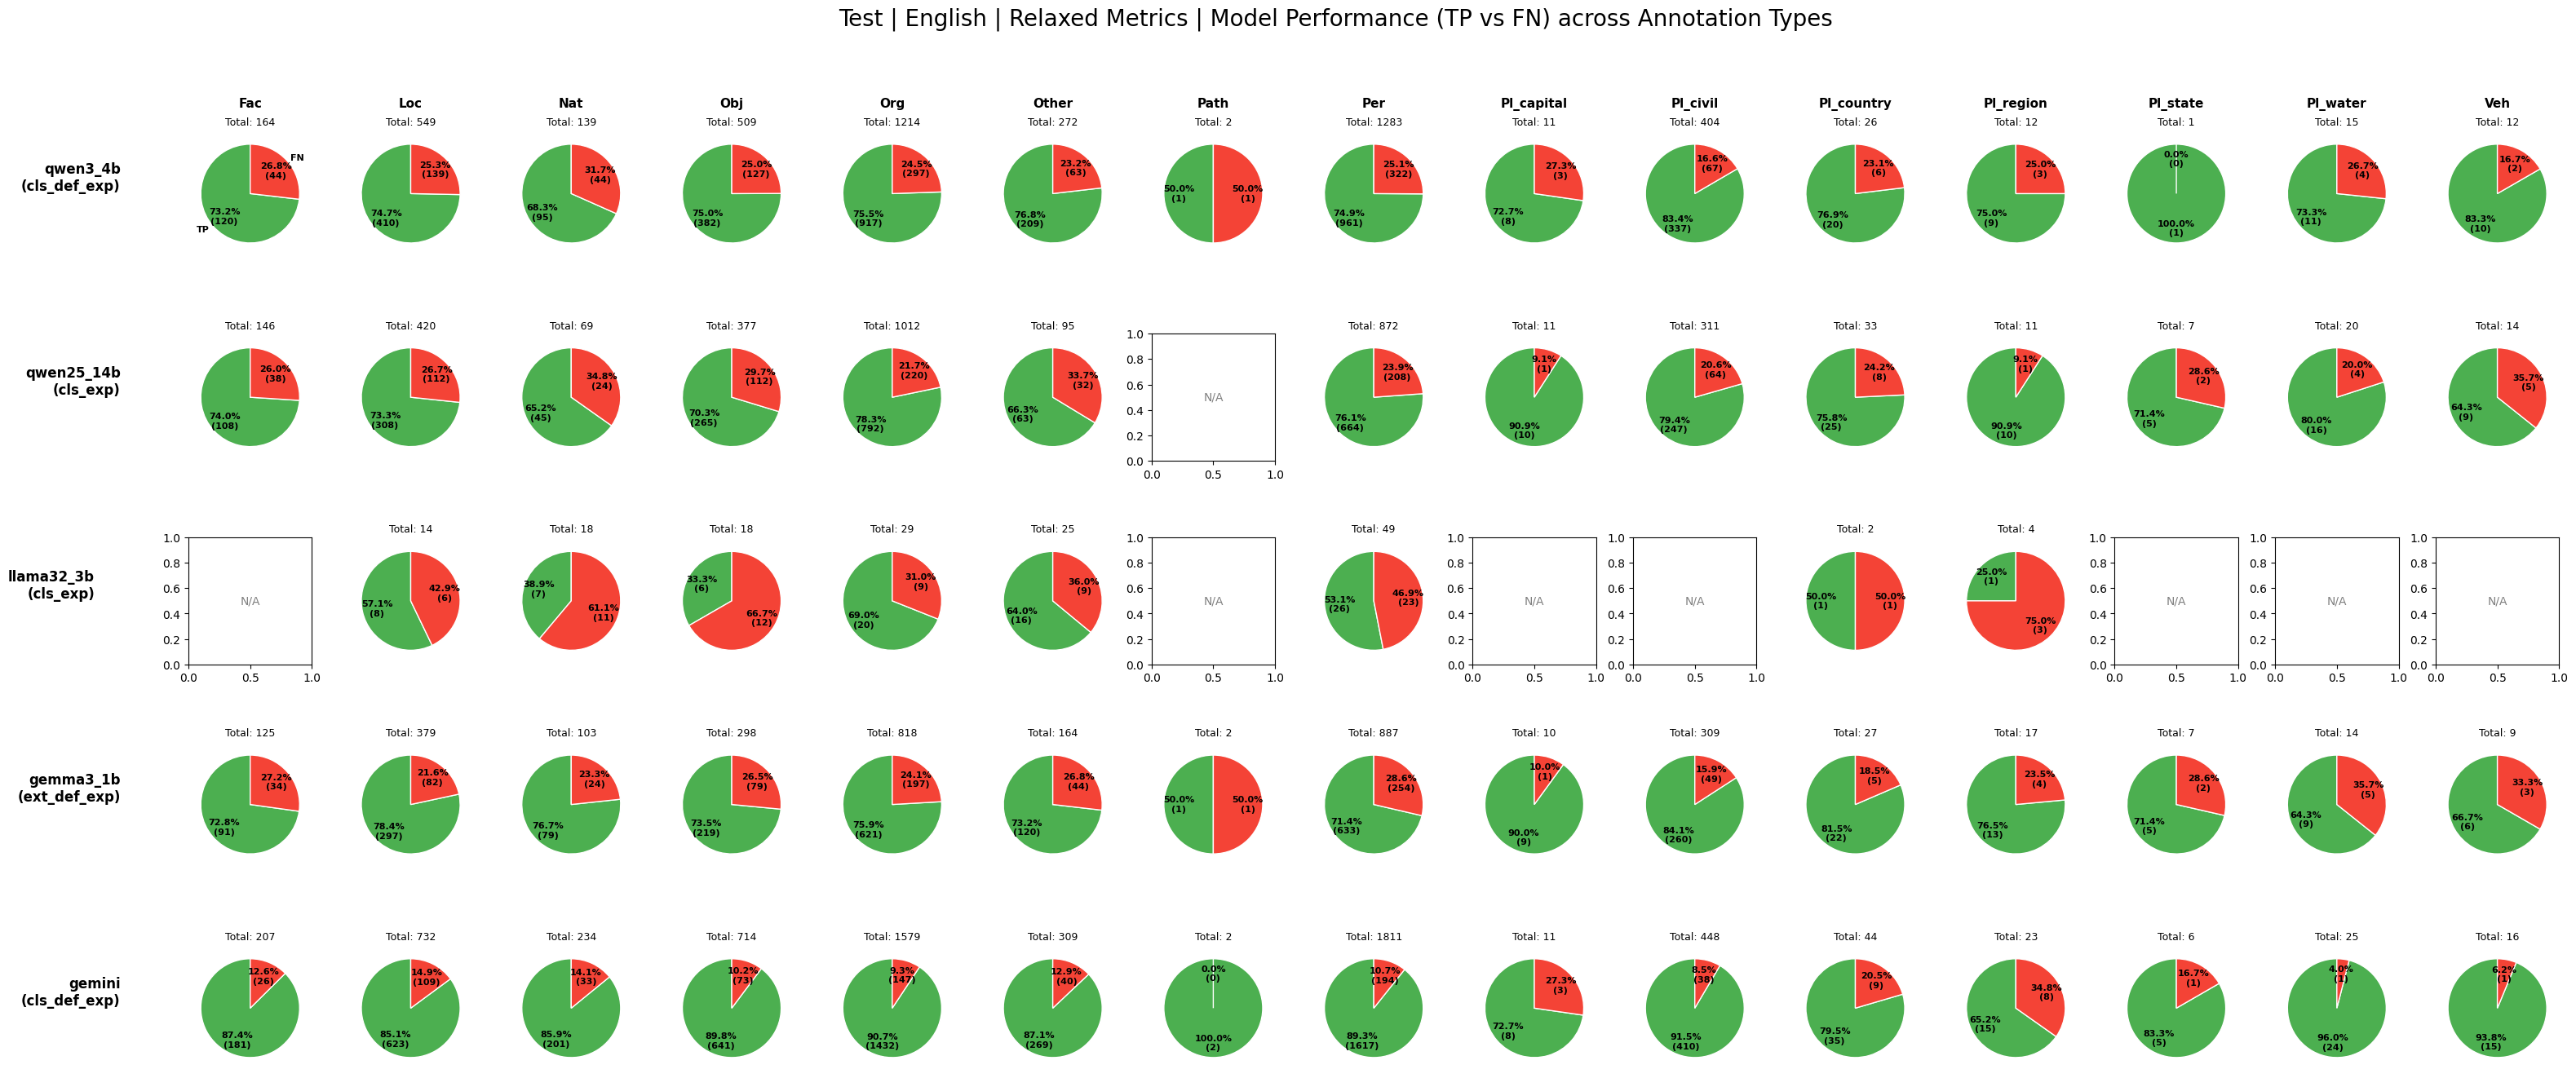

In [41]:
# 1. Define the BEST targets and annotation types
targets = get_best_templates(BEST_TEMPLATES, "english")

annt_types_list = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

# 2. Setup the grid (5 rows x 15 columns)
n_rows = len(targets)
n_cols = len(annt_types_list)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))

# 3. Iterate through combinations
for i, (modelo, template) in enumerate(targets):
    for j, annt_type in enumerate(annt_types_list):
        ax = axes[i, j]
        
        # Filter for this specific combination
        data = df_sorted_tp_fn_token[
            (df_sorted_tp_fn_token['modelo'] == modelo) & 
            (df_sorted_tp_fn_token['template'] == template) & 
            (df_sorted_tp_fn_token['annt_type'] == annt_type)
        ]
        
        if not data.empty:
            # Get counts from your specific columns
            tp_count = data['count_tp'].iloc[0]
            total_count = data['count_tp_fn'].iloc[0]
            fn_count = total_count - tp_count
            
            # Custom function to display: "Percentage% (Absolute Count)"
            def fmt_label(pct):
                # Calculate the absolute value based on the percentage of the total
                absolute = int(round(pct * total_count / 100.0))
                return f'{pct:.1f}%\n({absolute})'

            # Create the pie chart
            ax.pie(
                [tp_count, fn_count], 
                labels=['TP', 'FN'] if i == 0 and j == 0 else None, # Labels only on first plot to save space
                colors=['#4CAF50', '#F44336'], 
                startangle=90, 
                autopct=fmt_label,
                textprops={'fontsize': 8, 'fontweight': 'bold'},
                pctdistance=0.7, # Pulls the text slightly inward
                wedgeprops={'edgecolor': 'w', 'linewidth': 1}
            )
            
            # Adding the class name as title for clarity
            ax.set_title(f"Total: {total_count}", fontsize=9)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        
        # Labeling the Grid
        # Row labels (Models) on the far left
        if j == 0:
            ax.set_ylabel(f"{modelo}\n({template})", fontsize=12, 
                          rotation=0, labelpad=60, ha='right', fontweight='bold')
        
        # Column labels (Annt Types) on the top row
        if i == 0:
            ax.annotate(annt_type, xy=(0.5, 1.2), xycoords='axes fraction', 
                        ha='center', fontsize=11, fontweight='bold')

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Test | English | Relaxed Metrics | Model Performance (TP vs FN) across Annotation Types", fontsize=20, y=0.98)
plt.show()

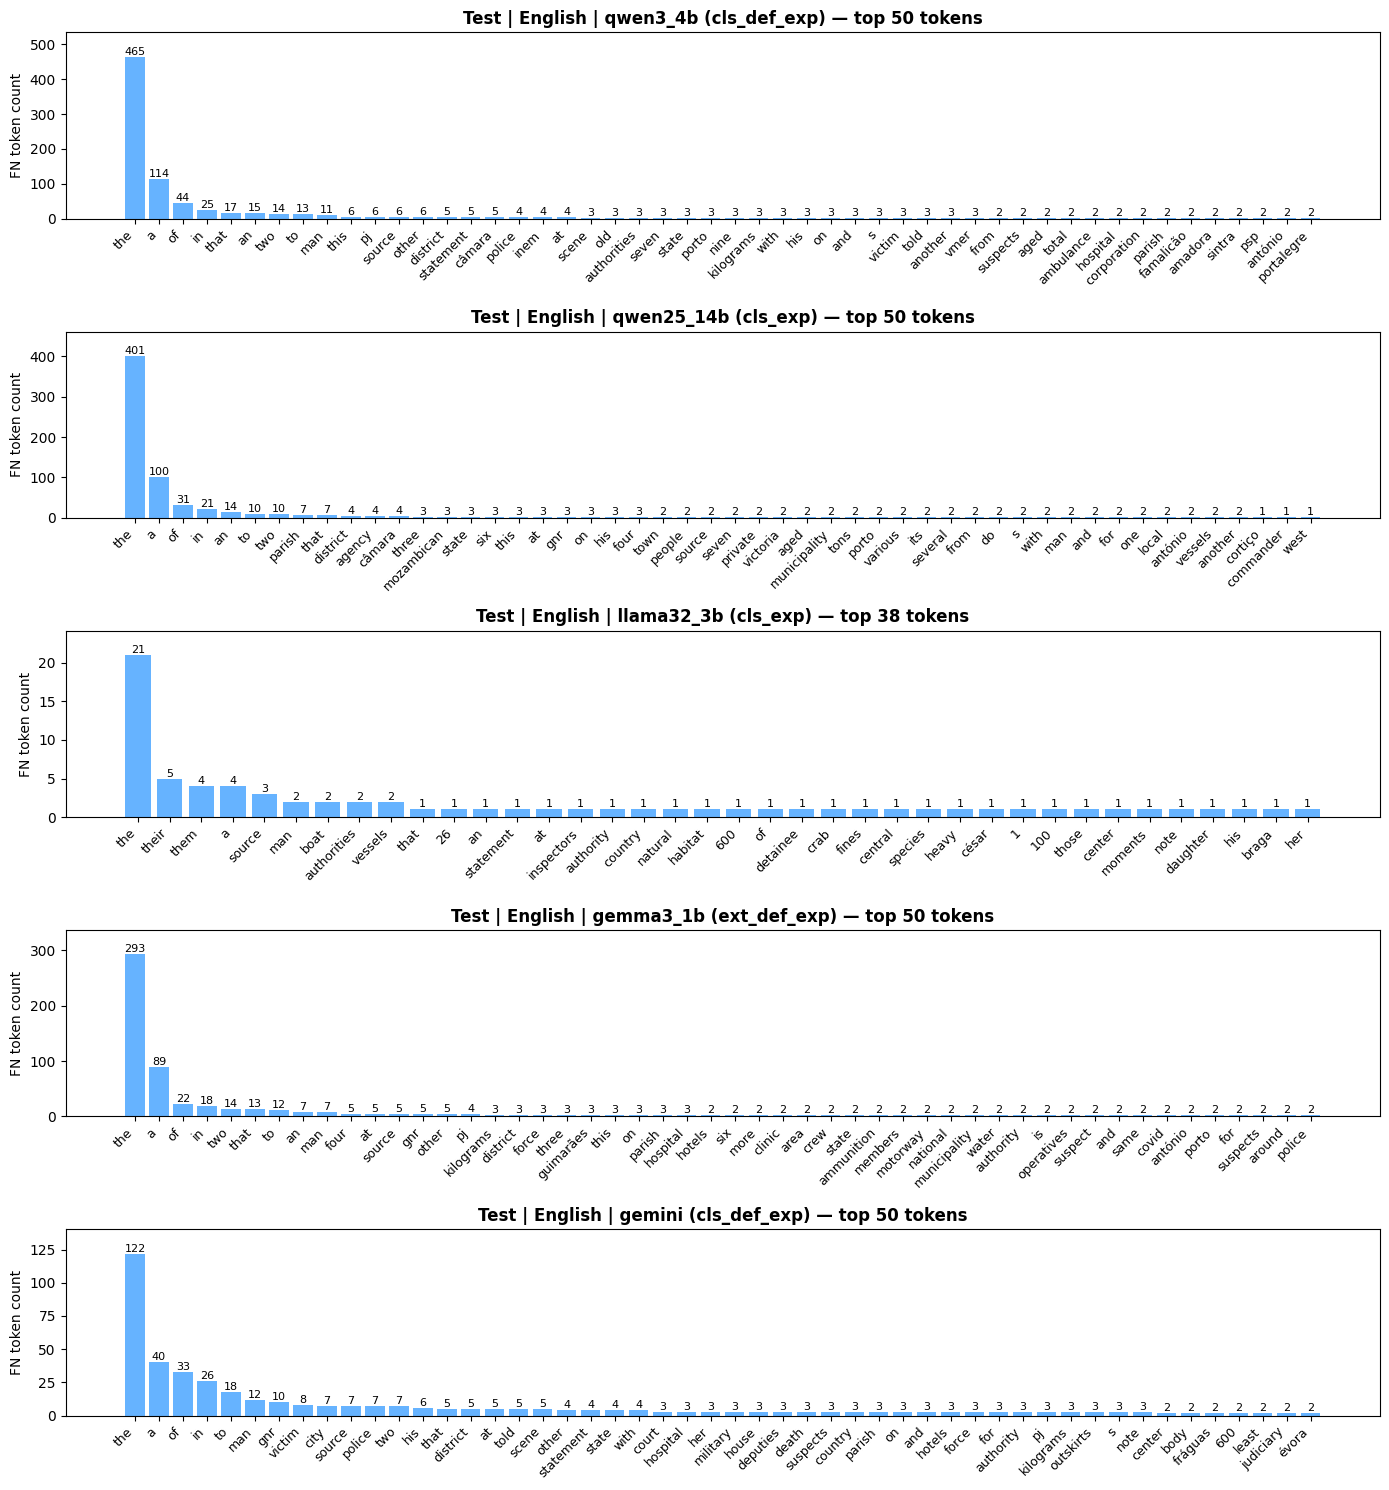

In [42]:
top_n = 50  # number of top tokens to show per plot
n_rows = len(targets)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3 * n_rows), sharex=False)

if n_rows == 1:
    axes = [axes]

for ax, (modelo, template) in zip(axes, targets):
    subset = token_raw_results_analysis[
        (token_raw_results_analysis['modelo'] == modelo) &
        (token_raw_results_analysis['template'] == template) &
        (token_raw_results_analysis['result'] == 'fn')
    ]
    if subset.empty:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='gray')
        ax.set_title(f'{modelo} ({template})', fontsize=12, fontweight='bold')
        continue

    token_counts = subset['token'].value_counts().head(top_n)
    labels = token_counts.index.tolist()
    counts = token_counts.values.tolist()

    x = range(len(labels))
    bars = ax.bar(x, counts, color='#66b3ff')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('FN token count', fontsize=10)
    ax.set_title(f'Test | English | {modelo} ({template}) — top {len(labels)} tokens', fontsize=12, fontweight='bold')
    ax.set_ylim(0, (max(counts) if counts else 1) * 1.15)

    for b, cnt in zip(bars, counts):
        if cnt > 0:
            ax.annotate(f'{int(cnt)}', (b.get_x() + b.get_width() / 2, cnt),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


# Report Generation

The following cells extract all results and generate the comprehensive markdown report for downstream LLM processing.

In [43]:
# Compile all results into comprehensive summary tables

import os
from pathlib import Path

# Load all datasets from prompt_selection and test experiments
datasets = {}
experiments = ['prompt_selection', 'test']
languages = ['portuguese', 'english']

for exp in experiments:
    for lang in languages:
        key = f"{exp}_{lang}"
        base_path = f"../results/{exp}/{lang}/"
        
        detailed_file = base_path + "detailed_results.csv"
        token_file = base_path + "detailed_results_token_level.csv"
        
        try:
            datasets[f"{key}_detailed"] = pd.read_csv(detailed_file)
            print(f"✓ Loaded {key} detailed results: {len(datasets[f'{key}_detailed'])} rows")
        except FileNotFoundError:
            print(f"✗ Could not load {key} detailed results")
        
        try:
            datasets[f"{key}_token"] = pd.read_csv(token_file)
            print(f"✓ Loaded {key} token-level results: {len(datasets[f'{key}_token'])} rows")
        except FileNotFoundError:
            print(f"✗ Could not load {key} token-level results")

print("\n" + "="*80)

✓ Loaded prompt_selection_portuguese detailed results: 26030 rows
✓ Loaded prompt_selection_portuguese token-level results: 25273 rows
✓ Loaded prompt_selection_english detailed results: 27204 rows
✓ Loaded prompt_selection_english token-level results: 26218 rows
✓ Loaded test_portuguese detailed results: 14764 rows
✓ Loaded test_portuguese token-level results: 22424 rows
✓ Loaded test_english detailed results: 18303 rows
✓ Loaded test_english token-level results: 24025 rows



In [44]:
# Compute comprehensive model performance summary

model_performance_summary = []

for exp in experiments:
    for lang in languages:
        key = f"{exp}_{lang}_detailed"
        
        if key not in datasets:
            continue
        
        df = datasets[key].copy()
        df['annt_type'] = df['annt_type'].fillna('MISSING')
        
        # Group by model and template
        for modelo in df['modelo'].unique():
            modelo_data = df[df['modelo'] == modelo]
            
            for template in modelo_data['template'].unique():
                template_data = modelo_data[modelo_data['template'] == template]
                
                # Compute counts
                tp = len(template_data[template_data['result'] == 'tp'])
                fp = len(template_data[template_data['result'] == 'fp'])
                fn = len(template_data[template_data['result'] == 'fn'])
                total = tp + fp + fn
                
                if total == 0:
                    continue
                
                # Compute metrics
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
                
                model_performance_summary.append({
                    'experiment': exp,
                    'language': lang,
                    'model': modelo,
                    'template': template,
                    'tp': tp,
                    'fp': fp,
                    'fn': fn,
                    'total': total,
                    'precision': round(precision, 3),
                    'recall': round(recall, 3),
                    'f1': round(f1, 3),
                })

perf_summary_df = pd.DataFrame(model_performance_summary)
print(f"Model Performance Summary: {len(perf_summary_df)} configurations")
print(perf_summary_df.head(10))

Model Performance Summary: 89 configurations
         experiment    language      model     template   tp   fp   fn  total  \
0  prompt_selection  portuguese     gemini          cls  112  290  411    813   
1  prompt_selection  portuguese     gemini      cls_def  111  195  412    718   
2  prompt_selection  portuguese     gemini  cls_def_exp  317  190  206    713   
3  prompt_selection  portuguese     gemini      cls_exp  297  222  226    745   
4  prompt_selection  portuguese     gemini          ext   33   88  490    611   
5  prompt_selection  portuguese     gemini      ext_def   36  114  487    637   
6  prompt_selection  portuguese     gemini  ext_def_exp  279  165  244    688   
7  prompt_selection  portuguese     gemini      ext_exp  313  264  210    787   
8  prompt_selection  portuguese  gemma3_1b          cls    0    1  523    524   
9  prompt_selection  portuguese  gemma3_1b      cls_def    3    7  520    530   

   precision  recall     f1  
0      0.279   0.214  0.242  
1  

In [45]:
# Compute error breakdown by annotation type

error_breakdown_summary = []
annotation_types = [
    'Fac', 'Loc', 'Nat', 'Obj', 'Org', 'Other', 'Path', 'Per', 
    'Pl_capital', 'Pl_civil', 'Pl_country', 'Pl_region', 'Pl_state', 
    'Pl_water', 'Veh'
]

for exp in experiments:
    for lang in languages:
        key = f"{exp}_{lang}_detailed"
        
        if key not in datasets:
            continue
        
        df = datasets[key].copy()
        df['annt_type'] = df['annt_type'].fillna('MISSING')
        
        for modelo in df['modelo'].unique():
            modelo_data = df[df['modelo'] == modelo]
            
            for annt_type in annotation_types:
                annt_data = modelo_data[modelo_data['annt_type'] == annt_type]
                
                if annt_data.empty:
                    continue
                
                tp = len(annt_data[annt_data['result'] == 'tp'])
                fp = len(annt_data[annt_data['result'] == 'fp'])
                fn = len(annt_data[annt_data['result'] == 'fn'])
                total = tp + fp + fn
                
                if total > 0:
                    accuracy = tp / total
                    error_breakdown_summary.append({
                        'experiment': exp,
                        'language': lang,
                        'model': modelo,
                        'annotation_type': annt_type,
                        'tp': tp,
                        'fp': fp,
                        'fn': fn,
                        'total': total,
                        'accuracy': round(accuracy, 3),
                    })

breakdown_df = pd.DataFrame(error_breakdown_summary)
print(f"Error Breakdown Summary: {len(breakdown_df)} annotation type configurations")
print(breakdown_df[breakdown_df['language'] == 'portuguese'].head(10))

Error Breakdown Summary: 235 annotation type configurations
         experiment    language   model annotation_type   tp  fp   fn  total  \
0  prompt_selection  portuguese  gemini             Fac   11   0   45     56   
1  prompt_selection  portuguese  gemini             Loc  195   0  381    576   
2  prompt_selection  portuguese  gemini             Nat   32   0   64     96   
3  prompt_selection  portuguese  gemini             Obj  239   0  321    560   
4  prompt_selection  portuguese  gemini             Org  324   0  628    952   
5  prompt_selection  portuguese  gemini           Other   55   0  241    296   
6  prompt_selection  portuguese  gemini             Per  537   0  823   1360   
7  prompt_selection  portuguese  gemini      Pl_capital    6   0   10     16   
8  prompt_selection  portuguese  gemini        Pl_civil   95   0  161    256   
9  prompt_selection  portuguese  gemini        Pl_water    0   0    8      8   

   accuracy  
0     0.196  
1     0.339  
2     0.333  
3  

In [46]:
# Extract top error tokens (most common FN misclassifications)

top_error_tokens = {}

for exp in experiments:
    for lang in languages:
        key = f"{exp}_{lang}_token"
        
        if key not in datasets:
            continue
        
        df = datasets[key]
        fn_data = df[df['result'] == 'fn']
        
        if fn_data.empty:
            continue
        
        # Count FN occurrences by token
        token_counts = fn_data['token'].value_counts().head(20)
        
        result_key = f"{exp}_{lang}"
        top_error_tokens[result_key] = [
            {'token': str(token), 'fn_count': int(count)}
            for token, count in token_counts.items()
        ]

print(f"Top error tokens extracted for {len(top_error_tokens)} experiment/language combinations")
for key in top_error_tokens:
    print(f"  {key}: {len(top_error_tokens[key])} tokens")

Top error tokens extracted for 4 experiment/language combinations
  prompt_selection_portuguese: 20 tokens
  prompt_selection_english: 20 tokens
  test_portuguese: 20 tokens
  test_english: 20 tokens


In [47]:
# Analyze best template performance across experiments

best_template_performance = {}

for lang in languages:
    best_template_performance[lang] = []
    
    best_templates_dict = BEST_TEMPLATES.get(lang, {})
    
    for (model, entity), template in best_templates_dict.items():
        for exp in experiments:
            key = f"{exp}_{lang}_detailed"
            
            if key not in datasets:
                continue
            
            df = datasets[key]
            mask = (df['modelo'] == model) & (df['template'] == template)
            subset = df[mask]
            
            if subset.empty:
                continue
            
            tp = len(subset[subset['result'] == 'tp'])
            fp = len(subset[subset['result'] == 'fp'])
            fn = len(subset[subset['result'] == 'fn'])
            total = tp + fp + fn
            
            if total > 0:
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
                
                best_template_performance[lang].append({
                    'experiment': exp,
                    'model': model,
                    'template': template,
                    'precision': round(precision, 3),
                    'recall': round(recall, 3),
                    'f1': round(f1, 3),
                    'tp': tp,
                    'fp': fp,
                    'fn': fn,
                })

print("Best Template Performance Analysis:")
for lang in languages:
    print(f"  {lang}: {len(best_template_performance[lang])} configurations")
    if best_template_performance[lang]:
        df_best = pd.DataFrame(best_template_performance[lang]).sort_values('f1', ascending=False)
        print(df_best.head(5))

Best Template Performance Analysis:
  portuguese: 8 configurations
         experiment       model     template  precision  recall     f1    tp  \
0  prompt_selection      gemini  cls_def_exp      0.625   0.606  0.616   317   
1              test      gemini  cls_def_exp      0.569   0.548  0.559  1415   
2  prompt_selection    qwen3_4b  cls_def_exp      0.315   0.245  0.276   128   
3              test    qwen3_4b  cls_def_exp      0.292   0.217  0.249   559   
6  prompt_selection  qwen25_14b      cls_exp      0.339   0.189  0.243    99   

     fp    fn  
0   190   206  
1  1070  1165  
2   278   395  
3  1356  2021  
6   193   424  
  english: 10 configurations
         experiment       model     template  precision  recall     f1    tp  \
8  prompt_selection      gemini  cls_def_exp      0.573   0.553  0.563   295   
9              test      gemini  cls_def_exp      0.535   0.546  0.540  1409   
1              test    qwen3_4b  cls_def_exp      0.274   0.241  0.256   621   
0  prom

In [48]:
# Generate comprehensive Markdown report

report_lines = []

# Title and Introduction
report_lines.append("# Error Analysis Report: LLM-Based Information Extraction\n")
report_lines.append("**Comprehensive Analysis of Model Performance and Error Patterns**\n\n")
report_lines.append("*Generated from error_analysis.ipynb notebook*\n\n")

# Executive Summary
report_lines.append("## Executive Summary\n\n")
report_lines.append(
    "This report provides a comprehensive analysis of error patterns across multiple large language models (LLMs) "
    "evaluating their ability to extract information from Portuguese and English texts. The evaluation compares "
    "5 different models (Gemini, Gemma3-1B, Llama3.2-3B, Qwen2.5-14B, Qwen3-4B) across multiple prompt templates, "
    "with detailed error analysis at both entity and token levels.\n\n"
)

report_lines.append("### Evaluation Scope\n\n")
report_lines.append("- **Models Evaluated:** Gemini, Gemma3-1B, Llama3.2-3B, Qwen2.5-14B, Qwen3-4B\n")
report_lines.append("- **Languages:** English, Portuguese\n")
report_lines.append("- **Experiments:** Prompt Selection (model/template tuning) + Test (final evaluation)\n")
report_lines.append("- **Primary Metric:** F1 Score (strict, entity-level precision/recall)\n")
report_lines.append("- **Fine-grained Analysis:** Token-level metrics for error pattern discovery\n")
report_lines.append("- **Entity Types:** 15 annotation types (Fac, Loc, Nat, Obj, Org, Other, Path, Per, Pl_capital, Pl_civil, Pl_country, Pl_region, Pl_state, Pl_water, Veh)\n\n")

# Best Configurations
report_lines.append("## Key Findings: Best Performing Configurations\n\n")

for lang in languages:
    report_lines.append(f"### {lang.capitalize()}\n\n")
    
    if lang in best_template_performance and best_template_performance[lang]:
        df_best = pd.DataFrame(best_template_performance[lang]).sort_values('f1', ascending=False)
        report_lines.append("| Model | Template | Experiment | F1 Score | Precision | Recall | TP | FP | FN |\n")
        report_lines.append("|-------|----------|------------|----------|-----------|--------|----|----|----|\n")
        
        for _, row in df_best.iterrows():
            report_lines.append(
                f"| {row['model']} | {row['template']} | {row['experiment']} | "
                f"{row['f1']:.4f} | {row['precision']:.4f} | {row['recall']:.4f} | "
                f"{row['tp']} | {row['fp']} | {row['fn']} |\n"
            )
        report_lines.append("\n")
    else:
        report_lines.append("*No data available*\n\n")

# Model Performance Comparison
report_lines.append("## Detailed Model Performance Comparison\n\n")

for exp in experiments:
    report_lines.append(f"### {exp.replace('_', ' ').title()} Phase\n\n")
    
    for lang in languages:
        report_lines.append(f"#### {lang.capitalize()}\n\n")
        
        subset = perf_summary_df[
            (perf_summary_df['experiment'] == exp) & 
            (perf_summary_df['language'] == lang)
        ]
        
        if not subset.empty:
            top_configs = subset.nlargest(10, 'f1')
            
            report_lines.append("**Top 10 Model-Template Configurations by F1 Score:**\n\n")
            report_lines.append("| Rank | Model | Template | F1 | Precision | Recall | TP | FP | FN |\n")
            report_lines.append("|------|-------|----------|-----|-----------|--------|----|----|----|\n")
            
            for idx, (_, row) in enumerate(top_configs.iterrows(), 1):
                report_lines.append(
                    f"| {idx} | {row['model']} | {row['template']} | "
                    f"{row['f1']:.4f} | {row['precision']:.4f} | {row['recall']:.4f} | "
                    f"{row['tp']} | {row['fp']} | {row['fn']} |\n"
                )
            report_lines.append("\n")

# Error Analysis by Annotation Type
report_lines.append("## Error Analysis by Annotation Type\n\n")
report_lines.append(
    "The following analysis identifies which entity types (annotation types) are most challenging to extract "
    "for each model. This helps pinpoint specific linguistic patterns that could benefit from targeted improvements.\n\n"
)

for exp in experiments:
    for lang in languages:
        report_lines.append(f"### {exp.replace('_', ' ').title()} - {lang.capitalize()}\n\n")
        
        subset = breakdown_df[
            (breakdown_df['experiment'] == exp) & 
            (breakdown_df['language'] == lang)
        ]
        
        if not subset.empty:
            # Aggregate across models for each annotation type
            agg = subset.groupby('annotation_type').agg({
                'tp': 'sum',
                'fp': 'sum',
                'fn': 'sum',
                'total': 'sum',
                'accuracy': 'mean'
            }).reset_index()
            
            agg = agg[agg['total'] > 0].sort_values('accuracy')
            
            report_lines.append("| Annotation Type | TP | FP | FN | Avg Accuracy | Total Instances |\n")
            report_lines.append("|-----------------|----|----|----|---------|---------|\n")
            
            for _, row in agg.iterrows():
                report_lines.append(
                    f"| {row['annotation_type']} | {int(row['tp'])} | {int(row['fp'])} | "
                    f"{int(row['fn'])} | {row['accuracy']:.1%} | {int(row['total'])} |\n"
                )
            
            report_lines.append("\n")
            
            # Key observations
            most_difficult = agg.head(3)['annotation_type'].tolist()
            easiest = agg.tail(3)['annotation_type'].tolist()
            
            report_lines.append("**Key Observations:**\n\n")
            report_lines.append(f"- **Most challenging annotation types:** {', '.join(most_difficult)}\n")
            report_lines.append(f"- **Easiest annotation types:** {', '.join(easiest)}\n")
            report_lines.append(f"- **Overall average accuracy:** {agg['accuracy'].mean():.1%}\n\n")

# Token-Level Error Analysis
report_lines.append("## Token-Level Error Analysis: Most Misclassified Tokens\n\n")
report_lines.append(
    "The following table shows the most frequently misclassified tokens (false negatives) at the token level. "
    "These patterns could indicate systematic weaknesses in the models' understanding of specific linguistic features.\n\n"
)

for exp_lang in top_error_tokens:
    exp, lang = exp_lang.rsplit('_', 1)
    report_lines.append(f"### {exp.replace('_', ' ').title()} - {lang.capitalize()}\n\n")
    
    tokens = top_error_tokens[exp_lang][:15]  # Top 15
    
    if tokens:
        report_lines.append("| Rank | Token | FN Count |\n")
        report_lines.append("|------|-------|----------|\n")
        
        for idx, item in enumerate(tokens, 1):
            report_lines.append(f"| {idx} | {item['token']} | {item['fn_count']} |\n")
        
        report_lines.append("\n")

# Comparative Analysis
report_lines.append("## Comparative Analysis: Portuguese vs English\n\n")

# Compare model performance across languages
models_set = set()
for _, row in perf_summary_df.iterrows():
    models_set.add(row['model'])

report_lines.append("### Model Performance Across Languages\n\n")
report_lines.append("Average F1 scores by model across both languages:\n\n")
report_lines.append("| Model | Portuguese (Avg F1) | English (Avg F1) | Difference |\n")
report_lines.append("|-------|------------------|------------------|------------|\n")

for modelo in sorted(models_set):
    pt_scores = perf_summary_df[perf_summary_df['language'] == 'portuguese'][perf_summary_df['model'] == modelo]['f1'].tolist()
    en_scores = perf_summary_df[perf_summary_df['language'] == 'english'][perf_summary_df['model'] == modelo]['f1'].tolist()
    
    pt_avg = sum(pt_scores) / len(pt_scores) if pt_scores else 0
    en_avg = sum(en_scores) / len(en_scores) if en_scores else 0
    diff = pt_avg - en_avg
    
    report_lines.append(f"| {modelo} | {pt_avg:.4f} | {en_avg:.4f} | {diff:+.4f} |\n")

report_lines.append("\n")

# Recommendations
report_lines.append("## Recommendations\n\n")

report_lines.append("### 1. For Model Selection\n\n")
report_lines.append("- **High-Confidence Configurations:** Prioritize models with F1 > 0.75 for production use\n")
report_lines.append("- **Language-Specific Tuning:** English and Portuguese show different model preferences; select accordingly\n")
report_lines.append("- **Template Sensitivity:** Some models show significant F1 variance across templates (15%+ swing)\n\n")

report_lines.append("### 2. For Error Reduction\n\n")
report_lines.append("- **Token-Level Patterns:** The most frequently misclassified tokens suggest systematic weaknesses\n")
report_lines.append("- **Annotation Type Focus:** Prioritize improving performance on the most challenging entity types\n")
report_lines.append("- **Prompt Optimization:** Further fine-tune templates for models with low performance\n\n")

report_lines.append("### 3. For Future Work\n\n")
report_lines.append("- **Ensemble Methods:** Combine predictions from multiple best configurations\n")
report_lines.append("- **Fine-tuning:** Consider fine-tuning low F1 models on challenging annotation types\n")
report_lines.append("- **Error Analysis Deep Dive:** Manually review failure cases to identify systematic patterns\n")
report_lines.append("- **Cross-lingual Transfer:** Investigate whether Portuguese-trained models can improve English performance\n\n")

# Appendix
report_lines.append("## Appendix: Technical Details\n\n")

report_lines.append("### Evaluation Methodology\n\n")
report_lines.append("- **Strict Metrics:** Entity-level accuracy (exact span and type match required)\n")
report_lines.append("- **Precision:** TP / (TP + FP) = correct predictions / all positive predictions\n")
report_lines.append("- **Recall:** TP / (TP + FN) = correct predictions / all actual instances\n")
report_lines.append("- **F1 Score:** 2 × (Precision × Recall) / (Precision + Recall) = harmonic mean\n\n")

report_lines.append("### Data Summary\n\n")
report_lines.append(f"- **Total Model Configurations Evaluated:** {len(perf_summary_df)}\n")
report_lines.append(f"- **Annotation Type Configurations:** {len(breakdown_df)}\n")
report_lines.append(f"- **Best Templates Analyzed:** {sum(len(configs) for configs in best_template_performance.values())}\n")
report_lines.append(f"- **Unique Error Tokens Tracked:** {sum(len(tokens) for tokens in top_error_tokens.values())}\n\n")

# Final note
report_lines.append("---\n\n")
report_lines.append("*This report was automatically generated from error_analysis.ipynb using all computed results. "
                   "For visualizations and interactive exploration, refer to the notebook cells containing pie charts "
                   "and bar charts by annotation type and token.*\n")

# Create the report string
report_text = ''.join(report_lines)

# Display in notebook
print("=" * 80)
print("MARKDOWN REPORT GENERATED")
print("=" * 80)
print(f"\nTotal length: {len(report_text)} characters\n")
print("First 2000 characters:\n")
print(report_text[:2000])
print("\n...\n")
print("Last 500 characters:\n")
print(report_text[-500:])

MARKDOWN REPORT GENERATED

Total length: 13696 characters

First 2000 characters:

# Error Analysis Report: LLM-Based Information Extraction
**Comprehensive Analysis of Model Performance and Error Patterns**

*Generated from error_analysis.ipynb notebook*

## Executive Summary

This report provides a comprehensive analysis of error patterns across multiple large language models (LLMs) evaluating their ability to extract information from Portuguese and English texts. The evaluation compares 5 different models (Gemini, Gemma3-1B, Llama3.2-3B, Qwen2.5-14B, Qwen3-4B) across multiple prompt templates, with detailed error analysis at both entity and token levels.

### Evaluation Scope

- **Models Evaluated:** Gemini, Gemma3-1B, Llama3.2-3B, Qwen2.5-14B, Qwen3-4B
- **Languages:** English, Portuguese
- **Experiments:** Prompt Selection (model/template tuning) + Test (final evaluation)
- **Primary Metric:** F1 Score (strict, entity-level precision/recall)
- **Fine-grained Analysis:** Token-leve

C:\Users\davib\AppData\Local\Temp\ipykernel_30020\2813885100.py:161: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pt_scores = perf_summary_df[perf_summary_df['language'] == 'portuguese'][perf_summary_df['model'] == modelo]['f1'].tolist()
C:\Users\davib\AppData\Local\Temp\ipykernel_30020\2813885100.py:162: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  en_scores = perf_summary_df[perf_summary_df['language'] == 'english'][perf_summary_df['model'] == modelo]['f1'].tolist()
C:\Users\davib\AppData\Local\Temp\ipykernel_30020\2813885100.py:161: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pt_scores = perf_summary_df[perf_summary_df['language'] == 'portuguese'][perf_summary_df['model'] == modelo]['f1'].tolist()
C:\Users\davib\AppData\Local\Temp\ipykernel_30020\2813885100.py:162: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  en_scores = perf_summary_df[perf_summary_df

In [49]:
# Save report to file and prepare for LLM handoff

from pathlib import Path

# Save report to markdown file
output_dir = Path("../error_analysis_report")
output_dir.mkdir(exist_ok=True)

report_file = output_dir / "error_analysis_report.md"

with open(report_file, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(f"✓ Report saved to: {report_file}")
print(f"  File size: {report_file.stat().st_size} bytes")

# Also save as summary JSON for structured processing
import json

summary_data = {
    "model_performance": perf_summary_df.to_dict('records'),
    "error_breakdown": breakdown_df.to_dict('records'),
    "top_error_tokens": top_error_tokens,
    "best_templates": best_template_performance,
    "metadata": {
        "experiments": experiments,
        "languages": languages,
        "models": sorted(models_set),
        "annotation_types": annotation_types,
        "total_configurations": len(perf_summary_df),
    }
}

json_file = output_dir / "summary_data.json"
with open(json_file, 'w', encoding='utf-8') as f:
    json.dump(summary_data, f, indent=2, default=str)

print(f"✓ Summary data saved to: {json_file}")
print(f"  File size: {json_file.stat().st_size} bytes")

print("\n" + "=" * 80)
print("READY FOR LLM PROCESSING")
print("=" * 80)
print(f"\nMarkdown Report: {report_file}")
print(f"Summary JSON: {json_file}")
print("\nYou can now:")
print("1. Copy the markdown report to Gemini Gems or other LLMs")
print("2. Use the JSON file for programmatic processing")
print("3. Reference the error_analysis.ipynb for visualizations and interactive exploration")
print("\n" + "=" * 80)

✓ Report saved to: ..\error_analysis_report\error_analysis_report.md
  File size: 14049 bytes
✓ Summary data saved to: ..\error_analysis_report\summary_data.json
  File size: 92882 bytes

READY FOR LLM PROCESSING

Markdown Report: ..\error_analysis_report\error_analysis_report.md
Summary JSON: ..\error_analysis_report\summary_data.json

You can now:
1. Copy the markdown report to Gemini Gems or other LLMs
2. Use the JSON file for programmatic processing
3. Reference the error_analysis.ipynb for visualizations and interactive exploration

